# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [4]:
# !pip install mat73 h5py numpy pandas matplotlib seaborn scikit-learn

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [10]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '/Users/jeongwon/Desktop/SKALA/data-mini/data'
)

batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : /Users/jeongwon/Desktop/SKALA/data-mini/data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)
   README.md  (0.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함

In [11]:
def load_battery_batch(path):
    """
    배터리 batch .mat 파일 로드 및 표준화 함수
    
    Parameters:
        path (str): .mat 파일 경로
    
    Returns:
        list[dict]: 각 배터리 셀 정보를 담은 list of dict
    """
    print(f"로딩 중... ({os.path.basename(path)})")

    # 1. 파일 로드 (버전 자동 감지)
    try:
        mat = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        mat = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")

    # 2. batch 추출
    if 'batch' not in mat:
        raise KeyError("'batch' 키가 존재하지 않습니다.")

    batch = mat['batch']

    # 3. 형식 통일 (list of dict)
    if isinstance(batch, dict):
        # mat73 케이스
        keys = list(batch.keys())
        n_cells = len(batch[keys[0]])
        batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
        print("mat73 형식 → list of dict 변환 완료")

    # 4. 검증 로그
    print(f"배터리 셀 수 : {len(batch)}")
    print(f"데이터 타입  : {type(batch)}")
    print(f"첫 번째 셀 키: {list(batch[0].keys())}")

    return batch

In [12]:
batch1 = load_battery_batch(batch1_path)
batch2 = load_battery_batch(batch2_path)
batch3 = load_battery_batch(batch3_path)

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (2017-05-12_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)
mat73 형식 → list of dict 변환 완료
배터리 셀 수 : 46
데이터 타입  : <class 'list'>
첫 번째 셀 키: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
로딩 중... (2018-02-20_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)
mat73 형식 → list of dict 변환 완료
배터리 셀 수 : 47
데이터 타입  : <class 'list'>
첫 번째 셀 키: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
로딩 중... (2018-04-12_batchdata_updated_struct_errorcorrect.mat)
로드 완료 (MATLAB v7.3 / HDF5 형식)
mat73 형식 → list of dict 변환 완료
배터리 셀 수 : 46
데이터 타입  : <class 'list'>
첫 번째 셀 키: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [13]:
# 단일 셀 구조 상세 확인
cell0 = batch1[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [14]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## 전처리 (minimum)
- cycle_life 자체가 NaN 값인 경우 해당 cell drop

In [15]:
def filter_valid_cells(batch):
    """
    cycle_life가 NaN인 cell 제거
    
    Parameters:
        batch (list of dict)
    
    Returns:
        filtered_batch (list of dict)
    """
    filtered_batch = []
    dropped_indices = []

    for i, cell in enumerate(batch):
        try:
            cycle_life = np.asarray(cell["cycle_life"]).item()

            # NaN 체크
            if cycle_life is None or np.isnan(cycle_life):
                dropped_indices.append(i)
                continue

            filtered_batch.append(cell)

        except Exception:
            dropped_indices.append(i)

    print(f"전체 cell 수      : {len(batch)}")
    print(f"유효 cell 수      : {len(filtered_batch)}")
    print(f"제거된 cell 수    : {len(dropped_indices)}")
    print(f"제거된 인덱스     : {dropped_indices}\n")

    return filtered_batch

In [16]:
batch1 = filter_valid_cells(batch1)
batch2 = filter_valid_cells(batch2)
batch3 = filter_valid_cells(batch3)

전체 cell 수      : 46
유효 cell 수      : 46
제거된 cell 수    : 0
제거된 인덱스     : []

전체 cell 수      : 47
유효 cell 수      : 39
제거된 cell 수    : 8
제거된 인덱스     : [22, 23, 35, 36, 37, 38, 39, 40]

전체 cell 수      : 46
유효 cell 수      : 44
제거된 cell 수    : 2
제거된 인덱스     : [23, 32]



## EDA(Basic)

### 1. Cycle Life 분포는 어떻게 생겼는가? 

In [17]:
def extract_cell_meta(batch, batch_name="batch"):
    """
    batch(list of dict)에서 cell-level meta dataframe 생성
    - cycle_life가 NaN인 cell은 제외
    """
    records = []

    for cell_id, cell in enumerate(batch):
        try:
            raw_cycle = np.asarray(cell["cycle_life"]).item()

            if raw_cycle is None or np.isnan(raw_cycle):
                continue

            charging_policy = str(
                cell.get("policy_readable") or cell.get("policy") or "unknown"
            )

            records.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "cycle_life": int(raw_cycle),
                "charging_policy": charging_policy
            })

        except Exception as e:
            print(f"[{batch_name}] cell {cell_id} 처리 실패: {e}")

    df = pd.DataFrame(records)
    return df

In [ ]:
def analyze_cycle_life_eda(
    cell_meta_df,
    batch_name="batch",
    feature_df=None,
    hist_range=(150, 2300),
    bins=20,
    short_threshold=500,
    long_threshold=1000
):
    """
    Q1. Cycle Life 분포 EDA
    - Histogram
    - 장수명/단수명 비율
    - IQR 기준 이상치 식별
    - charging_policy별 cycle_life 통계/boxplot
    - feature_df가 있으면 단수명 셀 확인
    """
    if cell_meta_df.empty:
        print(f"[{batch_name}] 유효한 데이터가 없습니다.")
        return {
            "summary": None,
            "ratio": None,
            "outlier_df": pd.DataFrame(),
            "policy_stats": pd.DataFrame()
        }

    print(f"\n{'='*80}")
    print(f"[{batch_name}] cell_meta_df shape: {cell_meta_df.shape}")
    display(cell_meta_df.head())

    # 1. Histogram
    plt.figure(figsize=(7, 4))
    plt.hist(
        cell_meta_df["cycle_life"],
        bins=bins,
        range=hist_range,
        edgecolor="black"
    )
    plt.xlabel("Cycle Life")
    plt.ylabel("Count")
    plt.title(f"{batch_name} - Cycle Life Distribution ({hist_range[0]} ~ {hist_range[1]})")
    plt.grid()
    plt.show()

    # 2. describe
    summary = cell_meta_df["cycle_life"].describe()
    print(f"\n[{batch_name}] Cycle Life Summary")
    print(summary)

    # 3. 장수명 / 단수명 비율
    n_total = len(cell_meta_df)
    n_long = (cell_meta_df["cycle_life"] > long_threshold).sum()
    n_short = (cell_meta_df["cycle_life"] < short_threshold).sum()
    n_others = n_total - n_long - n_short

    ratio_df = pd.DataFrame({
        "group": [f"long_life_>{long_threshold}", f"short_life_<{short_threshold}", "others"],
        "count": [n_long, n_short, n_others],
        "ratio": [n_long / n_total, n_short / n_total, n_others / n_total]
    })

    print(f"\n[{batch_name}] 전체 셀 수: {n_total}")
    print(f"[{batch_name}] 장수명 셀 수 (>{long_threshold}): {n_long} ({n_long / n_total:.1%})")
    print(f"[{batch_name}] 단수명 셀 수 (<{short_threshold}): {n_short} ({n_short / n_total:.1%})")
    print(f"[{batch_name}] 기타 셀 수: {n_others} ({n_others / n_total:.1%})")

    plt.figure(figsize=(6, 4))
    plt.bar(ratio_df["group"], ratio_df["count"])
    plt.ylabel("Count")
    plt.title(f"{batch_name} - Long / Short / Others Ratio")
    plt.grid(axis="y")
    plt.show()

    # 4. IQR 이상치
    q1 = cell_meta_df["cycle_life"].quantile(0.25)
    q3 = cell_meta_df["cycle_life"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_df = cell_meta_df[
        (cell_meta_df["cycle_life"] < lower_bound) |
        (cell_meta_df["cycle_life"] > upper_bound)
    ].sort_values("cycle_life")

    print(f"\n[{batch_name}] IQR 기준")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    print(f"\n[{batch_name}] IQR 기준 이상치 셀")
    display(outlier_df)

    # 5. charging_policy별 통계
    policy_stats = (
        cell_meta_df
        .groupby("charging_policy")["cycle_life"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean")
    )

    print(f"\n[{batch_name}] Charging Policy별 Cycle Life 통계")
    display(policy_stats)

    plt.figure(figsize=(12, 5))
    cell_meta_df.boxplot(column="cycle_life", by="charging_policy", rot=90)
    plt.title(f"{batch_name} - Cycle Life by Charging Policy")
    plt.suptitle("")
    plt.xlabel("Charging Policy")
    plt.ylabel("Cycle Life")
    plt.grid()
    plt.show()

    # 6. 단수명 셀 상세 확인
    if feature_df is not None and not feature_df.empty:
        short_with_features = (
            feature_df[feature_df["cycle_life"] < short_threshold]
            .sort_values("cycle_life")
        )

        print(f"\n[{batch_name}] 단수명 셀(feature_df 기준)")
        display(short_with_features)

    return {
        "summary": summary,
        "ratio": ratio_df,
        "outlier_df": outlier_df,
        "policy_stats": policy_stats
    }

In [19]:
def compare_cycle_life_eda(
    batch_dict,
    feature_df_dict=None,
    hist_range=(150, 2300),
    bins=20,
    short_threshold=500,
    long_threshold=1000
):
    """
    여러 batch를 한 번에 비교 분석
    
    Parameters
    ----------
    batch_dict : dict
        예: {"batch1": batch1, "batch2": batch2, "batch3": batch3}
    feature_df_dict : dict or None
        예: {"batch1": feature_df1, "batch2": feature_df2, "batch3": feature_df3}
    """
    results = {}
    combined_meta = []

    for batch_name, batch in batch_dict.items():
        print(f"\n\n########## {batch_name} 분석 시작 ##########")

        cell_meta_df = extract_cell_meta(batch, batch_name=batch_name)
        combined_meta.append(cell_meta_df)

        feature_df = None
        if feature_df_dict is not None:
            feature_df = feature_df_dict.get(batch_name)

        result = analyze_cycle_life_eda(
            cell_meta_df=cell_meta_df,
            batch_name=batch_name,
            feature_df=feature_df,
            hist_range=hist_range,
            bins=bins,
            short_threshold=short_threshold,
            long_threshold=long_threshold
        )

        results[batch_name] = {
            "cell_meta_df": cell_meta_df,
            **result
        }

    # 전체 batch 통합 비교용 dataframe
    combined_meta_df = pd.concat(combined_meta, ignore_index=True)

    print(f"\n\n{'#'*30} 전체 배치 통합 비교 {'#'*30}")
    print(combined_meta_df.groupby("batch")["cycle_life"].describe())

    # batch별 histogram 겹쳐보기
    plt.figure(figsize=(8, 5))
    for batch_name, group_df in combined_meta_df.groupby("batch"):
        plt.hist(
            group_df["cycle_life"],
            bins=bins,
            range=hist_range,
            alpha=0.5,
            label=batch_name,
            edgecolor="black"
        )
    plt.xlabel("Cycle Life")
    plt.ylabel("Count")
    plt.title("Cycle Life Distribution Comparison")
    plt.legend()
    plt.grid()
    plt.show()

    # batch별 boxplot 비교
    plt.figure(figsize=(7, 5))
    combined_meta_df.boxplot(column="cycle_life", by="batch")
    plt.title("Cycle Life by Batch")
    plt.suptitle("")
    plt.xlabel("Batch")
    plt.ylabel("Cycle Life")
    plt.grid()
    plt.show()

    results["combined_meta_df"] = combined_meta_df
    return results



########## batch1 분석 시작 ##########

[batch1] cell_meta_df shape: (46, 4)


,batch,cell_id,cycle_life,charging_policy
0,batch1,0,1190,3.6C(80%)-3.6C
1,batch1,1,1179,3.6C(80%)-3.6C
2,batch1,2,1177,3.6C(80%)-3.6C
3,batch1,3,1226,4C(80%)-4C
4,batch1,4,1227,4C(80%)-4C


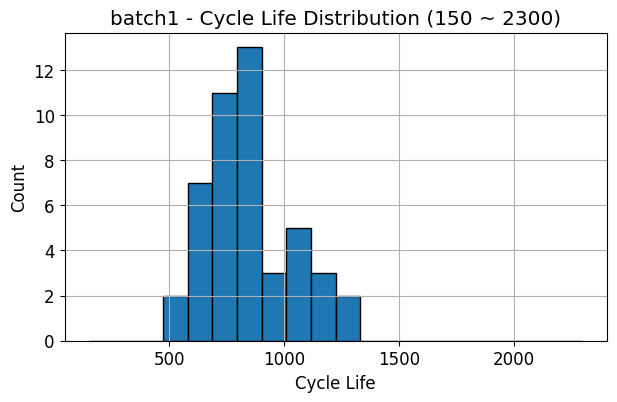


[batch1] Cycle Life Summary
count      46.000000
mean      844.717391
std       184.629198
min       534.000000
25%       703.250000
50%       858.500000
75%       914.250000
max      1227.000000
Name: cycle_life, dtype: float64

[batch1] 전체 셀 수: 46
[batch1] 장수명 셀 수 (>1000): 10 (21.7%)
[batch1] 단수명 셀 수 (<500): 0 (0.0%)
[batch1] 기타 셀 수: 36 (78.3%)


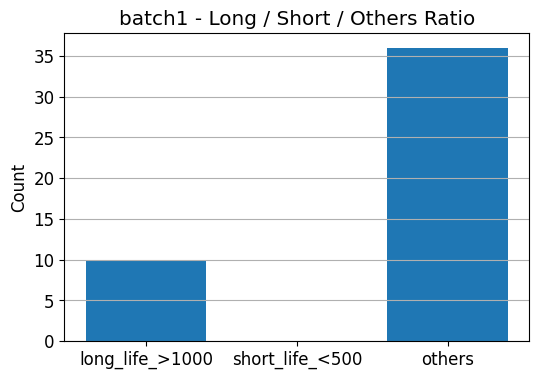


[batch1] IQR 기준
Q1: 703.25
Q3: 914.25
IQR: 211.0
Lower bound: 386.75
Upper bound: 1230.75

[batch1] IQR 기준 이상치 셀


,batch,cell_id,cycle_life,charging_policy



[batch1] Charging Policy별 Cycle Life 통계


,count,mean,median,min,max
charging_policy,,,,,
5.4C(80%)-5.4C,2,546.5,546.5,534,559
8C(35%)-3.6C,2,607.5,607.5,599,616
7C(40%)-3.6C,2,621.0,621.0,617,625
7C(40%)-3C,2,676.0,676.0,648,704
8C(25%)-3.6C,2,676.5,676.5,651,702
7C(30%)-3.6C,2,722.5,722.5,703,742
5.4C(70%)-3C,2,739.5,739.5,691,788
6C(60%)-3C,2,744.0,744.0,731,757
4.8C(80%)-4.8C,2,753.0,753.0,636,870


<Figure size 1200x500 with 0 Axes>

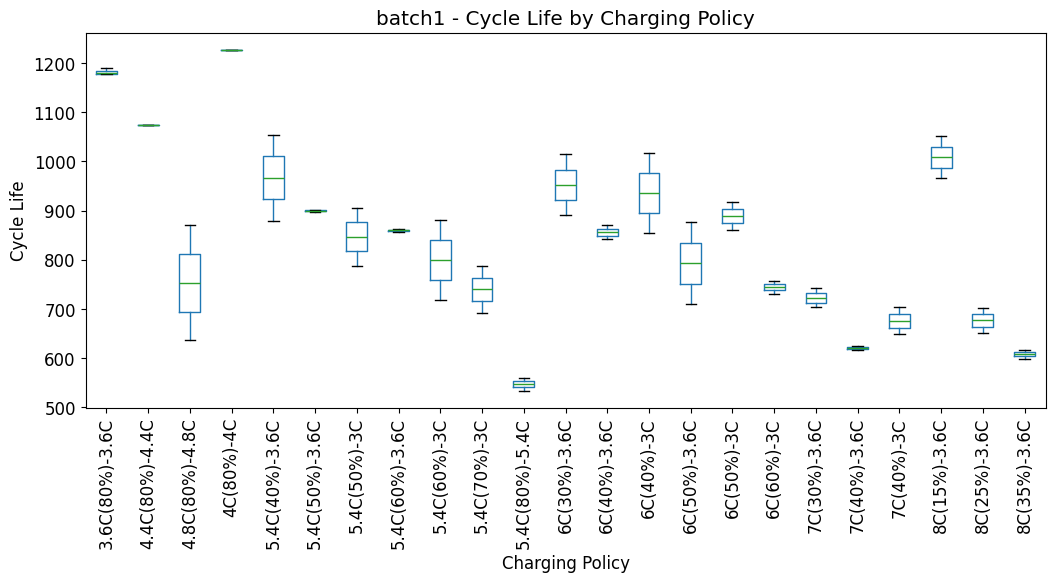



########## batch2 분석 시작 ##########

[batch2] cell_meta_df shape: (39, 4)


,batch,cell_id,cycle_life,charging_policy
0,batch2,0,477,5.2C(58%)-4C
1,batch2,1,491,5.6C(26%)-4.5C
2,batch2,2,424,5.2C(50%)-4.25C
3,batch2,3,499,4.65C(44%)-5C
4,batch2,4,444,4.65C(69%)-6C


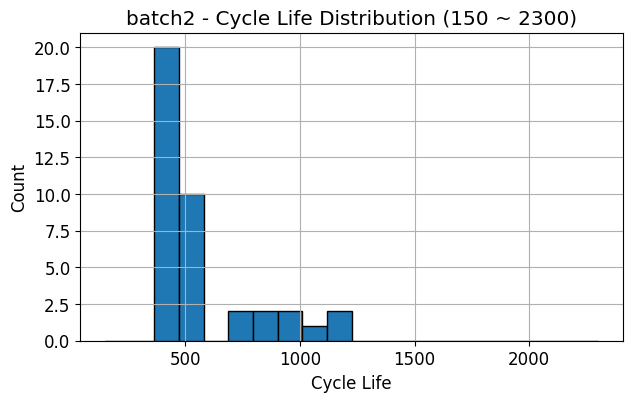


[batch2] Cycle Life Summary
count      39.000000
mean      565.743590
std       222.201629
min       392.000000
25%       439.500000
50%       472.000000
75%       508.500000
max      1186.000000
Name: cycle_life, dtype: float64

[batch2] 전체 셀 수: 39
[batch2] 장수명 셀 수 (>1000): 3 (7.7%)
[batch2] 단수명 셀 수 (<500): 28 (71.8%)
[batch2] 기타 셀 수: 8 (20.5%)


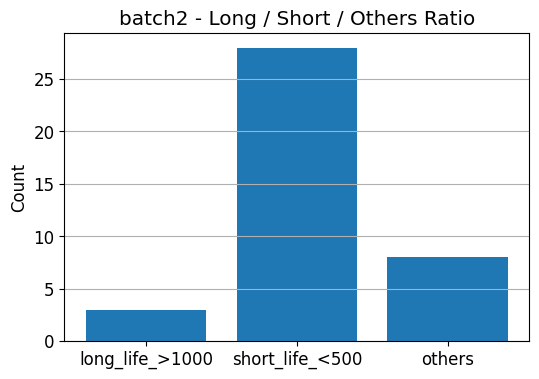


[batch2] IQR 기준
Q1: 439.5
Q3: 508.5
IQR: 69.0
Lower bound: 336.0
Upper bound: 612.0

[batch2] IQR 기준 이상치 셀


,batch,cell_id,cycle_life,charging_policy
7,batch2,7,777,4.8C(80%)-4.8C-newstructure
9,batch2,9,791,5.6C(26%)-4.5C-newstructure
30,batch2,30,809,4.8C(80%)-4.8C-newstructure
36,batch2,36,841,5.2C(58%)-4C-newstructure
8,batch2,8,904,5.2C(58%)-4C-newstructure
37,batch2,37,997,5.6C(26%)-4.5C-newstructure
35,batch2,35,1029,4.8C(80%)-4.8C-newstructure
31,batch2,31,1140,5.2C(58%)-4C-newstructure
32,batch2,32,1186,5.6C(26%)-4.5C-newstructure



[batch2] Charging Policy별 Cycle Life 통계


,count,mean,median,min,max
charging_policy,,,,,
3.6C(9%)-5C,2,394.500000,394.5,393,396
6C(60%)-3C,2,400.000000,400.0,392,408
3.6C(30%)-6C,2,421.000000,421.0,416,426
5.6C(26%)-4.5C,6,448.500000,446.0,412,491
4.65C(69%)-6C,2,452.000000,452.0,444,460
5.2C(50%)-4.25C,5,454.000000,449.0,424,474
5.2C(58%)-4C,4,477.750000,483.0,452,493
4.65C(44%)-5C,2,482.500000,482.5,466,499
4.8C(80%)-4.8C,5,483.600000,492.0,437,514


<Figure size 1200x500 with 0 Axes>

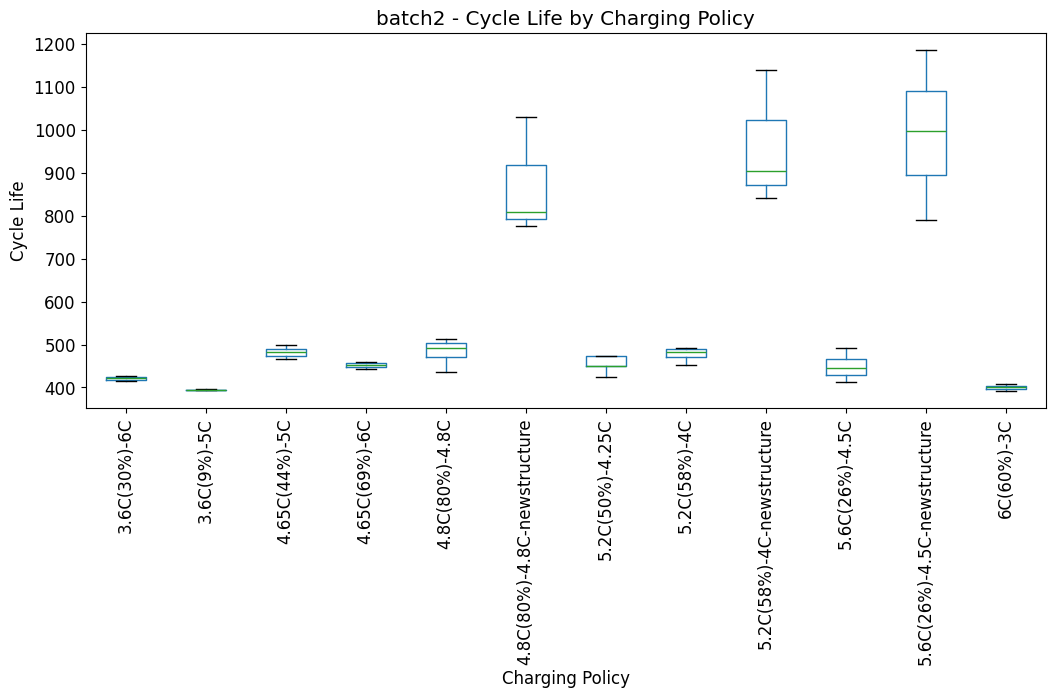



########## batch3 분석 시작 ##########

[batch3] cell_meta_df shape: (44, 4)


,batch,cell_id,cycle_life,charging_policy
0,batch3,0,1009,5C(67%)-4C-newstructure
1,batch3,1,1063,5.3C(54%)-4C-newstructure
2,batch3,2,1267,5.6C(19%)-4.6C-newstructure
3,batch3,3,1115,5.6C(36%)-4.3C-newstructure
4,batch3,4,1048,5.6C(19%)-4.6C-newstructure


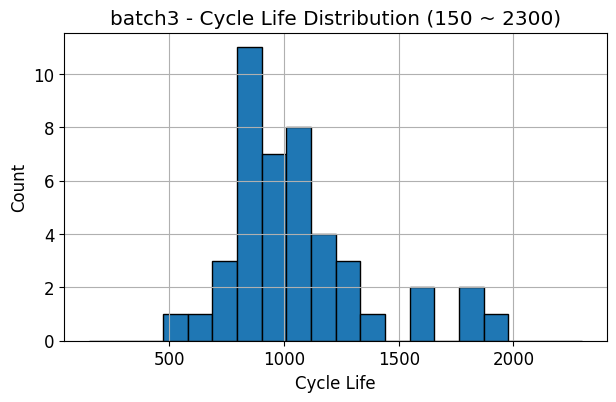


[batch3] Cycle Life Summary
count      44.000000
mean     1059.659091
std       313.869692
min       541.000000
25%       828.000000
50%      1005.500000
75%      1155.250000
max      1935.000000
Name: cycle_life, dtype: float64

[batch3] 전체 셀 수: 44
[batch3] 장수명 셀 수 (>1000): 23 (52.3%)
[batch3] 단수명 셀 수 (<500): 0 (0.0%)
[batch3] 기타 셀 수: 21 (47.7%)


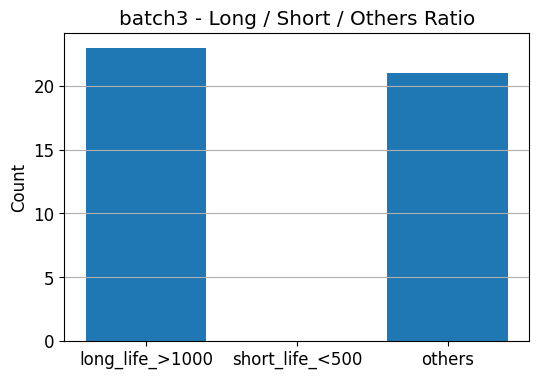


[batch3] IQR 기준
Q1: 828.0
Q3: 1155.25
IQR: 327.25
Lower bound: 337.125
Upper bound: 1646.125

[batch3] IQR 기준 이상치 셀


,batch,cell_id,cycle_life,charging_policy
43,batch3,43,1801,4.8C(80%)-4.8C-newstructure
7,batch3,7,1836,4.8C(80%)-4.8C-newstructure
36,batch3,36,1935,5C(67%)-4C-newstructure



[batch3] Charging Policy별 Cycle Life 통계


,count,mean,median,min,max
charging_policy,,,,,
3.7C(31%)-5.9C-newstructure,3,660.000000,667.0,541,772
5.9C(60%)-3.1C-newstructure,2,866.500000,866.5,731,1002
5.9C(15%)-4.6C-newstructure,2,867.000000,867.0,858,876
5.6C(36%)-4.3C-newstructure,8,930.875000,890.5,786,1155
5.6C(19%)-4.6C-newstructure,8,1001.375000,1038.0,796,1267
5.3C(54%)-4C-newstructure,8,1074.375000,1051.0,935,1315
5C(67%)-4C-newstructure,7,1105.714286,1009.0,813,1935
4.8C(80%)-4.8C-newstructure,6,1564.166667,1640.0,1078,1836


<Figure size 1200x500 with 0 Axes>

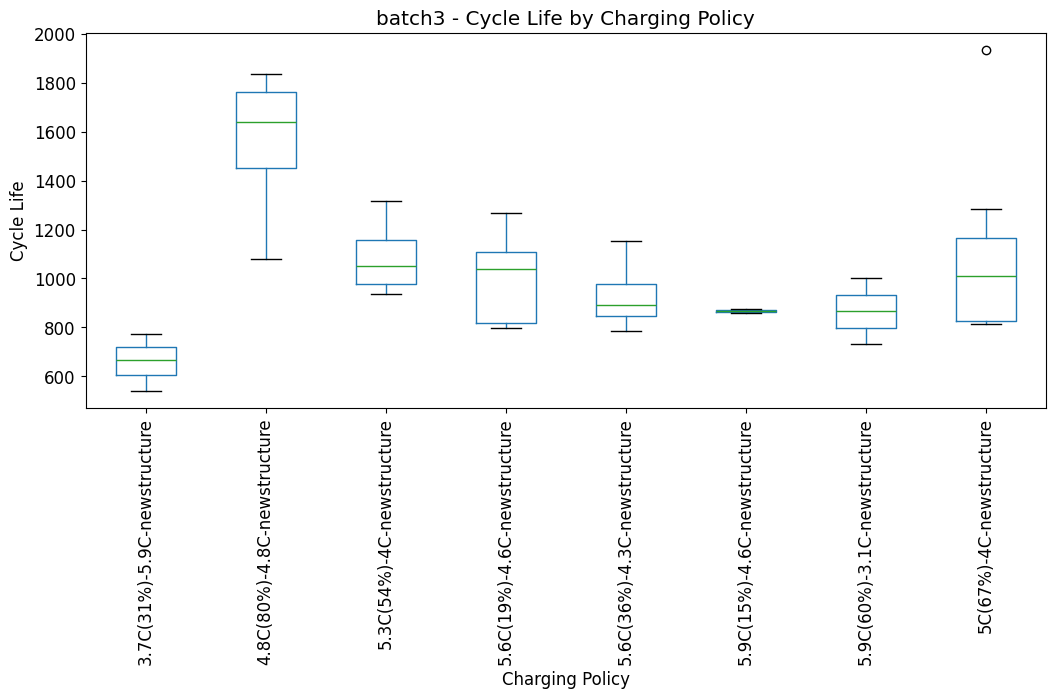



############################## 전체 배치 통합 비교 ##############################
        count         mean         std    min     25%     50%      75%     max
batch                                                                         
batch1   46.0   844.717391  184.629198  534.0  703.25   858.5   914.25  1227.0
batch2   39.0   565.743590  222.201629  392.0  439.50   472.0   508.50  1186.0
batch3   44.0  1059.659091  313.869692  541.0  828.00  1005.5  1155.25  1935.0


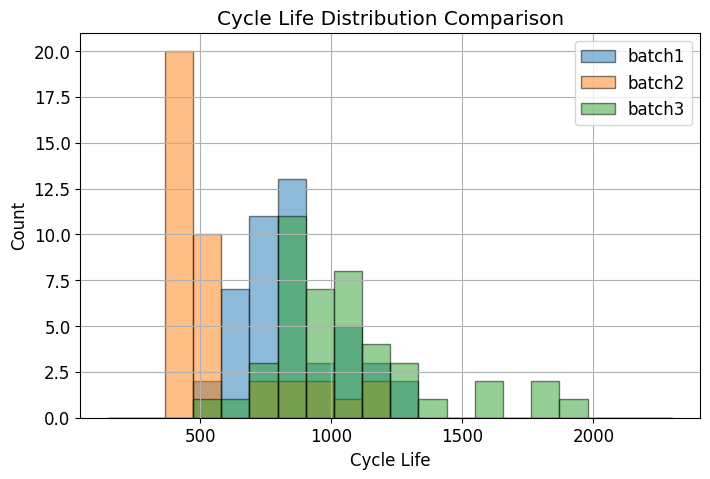

<Figure size 700x500 with 0 Axes>

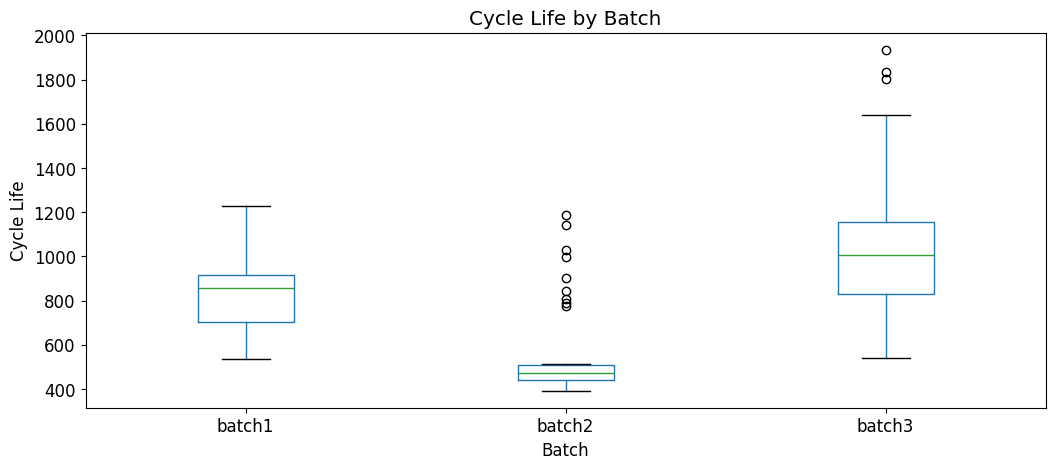

In [20]:
batch_dict = {
    "batch1": batch1,
    "batch2": batch2,
    "batch3": batch3
}

results = compare_cycle_life_eda(batch_dict)

### 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
    - 사이클 별 Qd 추이 시각화
    - 열화 속도가 일정한가, 가속되는가?
    - Knee point - 급격한 열화 시작점 탐색

In [22]:
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Direct EDA for Section 2
# - no image save/load
# - robust for mat73 dict-of-lists cycles structure
# =========================================================

BATCHES = {
    "batch1": batch1,
    "batch2": batch2,
    "batch3": batch3,
}

SHORT_LIFE_CUTOFF = 500
LONG_LIFE_CUTOFF = 1000


# -----------------------------
# basic helpers
# -----------------------------
def _to_scalar(x):
    """
    scalar / ndarray / list 어떤 형태든 최대한 float 하나로 변환
    """
    if x is None:
        return np.nan

    try:
        arr = np.asarray(x, dtype=float).reshape(-1)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return np.nan
        return float(arr[-1])
    except Exception:
        try:
            return float(x)
        except Exception:
            return np.nan


def _ensure_cycles_list(cycles_raw):
    """
    cycles 구조를 무조건 list of dict 로 맞춘다.
    - 이미 list면 그대로 사용
    - dict of lists면 list of dict로 변환
    """
    if cycles_raw is None:
        return []

    if isinstance(cycles_raw, list):
        return cycles_raw

    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        if len(keys) == 0:
            return []

        lengths = []
        for k in keys:
            try:
                lengths.append(len(cycles_raw[k]))
            except Exception:
                pass

        if len(lengths) == 0:
            return []

        n = min(lengths)
        out = []
        for i in range(n):
            row = {}
            for k in keys:
                try:
                    row[k] = cycles_raw[k][i]
                except Exception:
                    row[k] = None
            out.append(row)
        return out

    return []


def _extract_cycle_qd(cell):
    """
    cell['cycles']에서 cycle별 Qd를 추출
    """
    cycles = _ensure_cycles_list(cell.get("cycles"))
    qd_list = []

    for cyc in cycles:
        if not isinstance(cyc, dict):
            qd_list.append(np.nan)
            continue

        qd_val = cyc.get("Qd", None)
        qd_list.append(_to_scalar(qd_val))

    return np.asarray(qd_list, dtype=float)


def _filter_spikes_and_interpolate(y):
    """
    Qd 시계열에서 한 점 spike를 NaN 처리 후 선형보간
    """
    y = np.asarray(y, dtype=float).copy()
    n = len(y)

    if n < 5:
        return y

    valid_mask = np.isfinite(y)
    if valid_mask.sum() < 3:
        return y

    diff = np.diff(y[valid_mask])
    if diff.size == 0:
        return y

    med = np.median(diff)
    mad = np.median(np.abs(diff - med))
    threshold = max(0.005, 6 * mad)

    spike_idx = []
    for i in range(1, n - 1):
        if not (np.isfinite(y[i-1]) and np.isfinite(y[i]) and np.isfinite(y[i+1])):
            continue

        left = y[i] - y[i-1]
        right = y[i+1] - y[i]

        # 좌우가 큰 폭으로 반대로 움직이는 한 점 튐만 제거
        if abs(left) > threshold and abs(right) > threshold and np.sign(left) != np.sign(right):
            spike_idx.append(i)

    if spike_idx:
        y[spike_idx] = np.nan

    y = pd.Series(y).interpolate(method="linear", limit_direction="both").to_numpy(dtype=float)
    return y


def _safe_cycle_life(cell):
    try:
        v = np.asarray(cell["cycle_life"]).reshape(-1)
        if v.size == 0:
            return np.nan
        out = float(v[0])
        if np.isnan(out):
            return np.nan
        return int(out)
    except Exception:
        return np.nan


def _safe_policy(cell):
    try:
        return str(cell.get("policy_readable") or cell.get("policy") or "unknown")
    except Exception:
        return "unknown"


def _life_group(cycle_life):
    if pd.isna(cycle_life):
        return "unknown"
    if cycle_life < SHORT_LIFE_CUTOFF:
        return "short-life"
    elif cycle_life > LONG_LIFE_CUTOFF:
        return "long-life"
    return "others"


def _empty_qd_curve_df():
    return pd.DataFrame(columns=[
        "batch_label", "cell_id", "cycle_index", "Qd", "cycle_life", "life_group"
    ])


def _empty_feature_df():
    return pd.DataFrame(columns=[
        "batch_label", "cell_id", "cycle_life", "life_group", "charging_policy",
        "Qd_10", "Qd_50", "Qd_100",
        "Qd_delta_100_10", "Qd_retention_50", "Qd_retention_100", "Qd_retention_300",
        "Qd_drop_per_100", "drop_1_100", "drop_101_300", "drop_301_plus",
        "slope_1_100", "slope_101_300",
        "knee_point", "valid_knee", "knee_ratio",
        "accel_onset_cycle", "accel_onset_ratio",
        "cycle_to_99_retention", "cycle_to_95_retention", "cycle_to_90_retention"
    ])


def _make_qd_curve_frame(batch, batch_label, filtered=False):
    rows = []

    for cell_id, cell in enumerate(batch):
        cycle_life = _safe_cycle_life(cell)
        if pd.isna(cycle_life):
            continue

        qd = _extract_cycle_qd(cell)
        if qd.size == 0:
            continue

        if filtered:
            qd = _filter_spikes_and_interpolate(qd)

        life_group = _life_group(cycle_life)

        for idx, q in enumerate(qd, start=1):
            rows.append({
                "batch_label": batch_label,
                "cell_id": cell_id,
                "cycle_index": idx,
                "Qd": q,
                "cycle_life": cycle_life,
                "life_group": life_group,
            })

    if len(rows) == 0:
        return _empty_qd_curve_df()

    return pd.DataFrame(rows)


def _summarize_qd_by_group(qd_df):
    if qd_df.empty:
        return pd.DataFrame(columns=[
            "batch_label", "life_group", "cycle_index",
            "qd_median", "qd_q25", "qd_q75", "n"
        ])

    return (
        qd_df.dropna(subset=["Qd"])
        .groupby(["batch_label", "life_group", "cycle_index"])["Qd"]
        .agg(
            qd_median="median",
            qd_q25=lambda x: np.nanpercentile(x, 25),
            qd_q75=lambda x: np.nanpercentile(x, 75),
            n="count"
        )
        .reset_index()
    )


def _make_retention_features(batch, batch_label, filtered=True):
    rows = []

    for cell_id, cell in enumerate(batch):
        cycle_life = _safe_cycle_life(cell)
        if pd.isna(cycle_life):
            continue

        qd = _extract_cycle_qd(cell)
        if qd.size < 20:
            continue

        if filtered:
            qd = _filter_spikes_and_interpolate(qd)

        if not np.isfinite(qd[0]) or qd[0] == 0:
            continue

        baseline = qd[0]
        retention = qd / baseline

        def _ret_at(c):
            if len(retention) >= c:
                return float(retention[c-1])
            return np.nan

        def _qd_at(c):
            if len(qd) >= c:
                return float(qd[c-1])
            return np.nan

        def _drop_per_100(start_cycle, end_cycle):
            if len(retention) < end_cycle:
                return np.nan
            r1 = retention[start_cycle - 1]
            r2 = retention[end_cycle - 1]
            return (r1 - r2) / (end_cycle - start_cycle) * 100

        def _slope(start_cycle, end_cycle):
            if len(retention) < end_cycle:
                return np.nan
            y = retention[start_cycle-1:end_cycle]
            x = np.arange(start_cycle, end_cycle + 1)
            mask = np.isfinite(y)
            if mask.sum() < 3:
                return np.nan
            return np.polyfit(x[mask], y[mask], 1)[0]

        drop_1_100 = _drop_per_100(1, 100)
        drop_101_300 = _drop_per_100(101, 300) if len(retention) >= 300 else np.nan

        if len(retention) >= 301:
            drop_301_plus = (retention[300] - retention[-1]) / max(len(retention) - 301, 1) * 100
        else:
            drop_301_plus = np.nan

        # acceleration onset
        accel_onset = np.nan
        if len(retention) >= 120:
            win = 20
            slopes = []
            centers = []

            for start in range(0, len(retention) - win + 1):
                y = retention[start:start+win]
                x = np.arange(start + 1, start + win + 1)
                mask = np.isfinite(y)
                if mask.sum() < 5:
                    slopes.append(np.nan)
                else:
                    slopes.append(np.polyfit(x[mask], y[mask], 1)[0])
                centers.append(start + win // 2 + 1)

            slopes = np.asarray(slopes, dtype=float)
            centers = np.asarray(centers, dtype=int)

            early_mask = centers <= 100
            if np.isfinite(slopes[early_mask]).sum() >= 3:
                early_ref = np.nanmedian(slopes[early_mask])
                target = abs(early_ref) * 1.5

                for c, s in zip(centers, slopes):
                    if np.isfinite(s) and c > 50 and abs(s) >= target:
                        accel_onset = int(c)
                        break

        # simple knee candidate
        knee_point = np.nan
        valid_knee = False
        if len(retention) >= 30:
            y = pd.Series(retention).rolling(7, center=True, min_periods=1).median().to_numpy()
            if np.isfinite(y).sum() >= 10:
                d2 = np.diff(y, n=2)
                if len(d2) > 10 and np.isfinite(d2).sum() > 0:
                    kp = int(np.nanargmax(np.abs(d2[10:])) + 11)
                    knee_point = kp
                    valid_knee = True

        def _cycle_to_threshold(th):
            idx = np.where(retention <= th)[0]
            if len(idx) == 0:
                return np.nan
            return int(idx[0] + 1)

        rows.append({
            "batch_label": batch_label,
            "cell_id": cell_id,
            "cycle_life": cycle_life,
            "life_group": _life_group(cycle_life),
            "charging_policy": _safe_policy(cell),

            "Qd_10": _qd_at(10),
            "Qd_50": _qd_at(50),
            "Qd_100": _qd_at(100),

            "Qd_delta_100_10": (_qd_at(10) - _qd_at(100)) if np.isfinite(_qd_at(10)) and np.isfinite(_qd_at(100)) else np.nan,
            "Qd_retention_50": _ret_at(50),
            "Qd_retention_100": _ret_at(100),
            "Qd_retention_300": _ret_at(300),

            "Qd_drop_per_100": drop_1_100,
            "drop_1_100": drop_1_100,
            "drop_101_300": drop_101_300,
            "drop_301_plus": drop_301_plus,

            "slope_1_100": _slope(1, 100),
            "slope_101_300": _slope(101, 300),

            "knee_point": knee_point,
            "valid_knee": valid_knee,
            "knee_ratio": knee_point / cycle_life if np.isfinite(knee_point) and cycle_life > 0 else np.nan,

            "accel_onset_cycle": accel_onset,
            "accel_onset_ratio": accel_onset / cycle_life if np.isfinite(accel_onset) and cycle_life > 0 else np.nan,

            "cycle_to_99_retention": _cycle_to_threshold(0.99),
            "cycle_to_95_retention": _cycle_to_threshold(0.95),
            "cycle_to_90_retention": _cycle_to_threshold(0.90),
        })

    if len(rows) == 0:
        return _empty_feature_df()

    return pd.DataFrame(rows)


def _spearman_series(df, feature_cols, target_col="cycle_life"):
    rows = []

    if df.empty:
        return pd.DataFrame(columns=["batch_label", "feature", "spearman_with_cycle_life", "n"])

    for batch_label, sub in df.groupby("batch_label"):
        for feat in feature_cols:
            if feat not in sub.columns:
                continue

            tmp = sub[[feat, target_col]].dropna()
            if len(tmp) < 5:
                corr = np.nan
            else:
                corr = tmp[feat].corr(tmp[target_col], method="spearman")

            rows.append({
                "batch_label": batch_label,
                "feature": feat,
                "spearman_with_cycle_life": corr,
                "n": len(tmp),
            })

    return pd.DataFrame(rows)


def _display_group_table(df, title):
    display(Markdown(f"### {title}"))
    if df is None or len(df) == 0:
        display(Markdown("표시할 데이터가 없습니다."))
    else:
        display(df.reset_index(drop=True))


# -----------------------------
# build
# -----------------------------
qd_filtered_df = pd.concat(
    [_make_qd_curve_frame(batch, batch_label, filtered=True) for batch_label, batch in BATCHES.items()],
    ignore_index=True
)

qd_group_summary = _summarize_qd_by_group(qd_filtered_df)

feature_df = pd.concat(
    [_make_retention_features(batch, batch_label, filtered=True) for batch_label, batch in BATCHES.items()],
    ignore_index=True
)

print("qd_filtered_df shape:", qd_filtered_df.shape)
print("feature_df shape:", feature_df.shape)
display(qd_filtered_df.head())
display(feature_df.head())

qd_filtered_df shape: (108426, 6)
feature_df shape: (129, 26)


,batch_label,cell_id,cycle_index,Qd,cycle_life,life_group
0,batch1,0,1,1.070689,1190,long-life
1,batch1,0,2,1.070689,1190,long-life
2,batch1,0,3,1.071900,1190,long-life
3,batch1,0,4,1.072510,1190,long-life
4,batch1,0,5,1.073174,1190,long-life


,batch_label,cell_id,cycle_life,life_group,charging_policy,Qd_10,Qd_50,Qd_100,Qd_delta_100_10,Qd_retention_50,...,slope_1_100,slope_101_300,knee_point,valid_knee,knee_ratio,accel_onset_cycle,accel_onset_ratio,cycle_to_99_retention,cycle_to_95_retention,cycle_to_90_retention
0,batch1,0,1190,long-life,3.6C(80%)-3.6C,1.074537,1.076756,1.075913,-0.001375,1.005666,...,0.000019,-0.000035,388,True,0.326050,51,0.042857,258,NaN,NaN
1,batch1,1,1179,long-life,3.6C(80%)-3.6C,1.079777,1.081715,1.080630,-0.000853,1.005964,...,0.000008,-0.000025,849,True,0.720102,68,0.057676,594,NaN,NaN
2,batch1,2,1177,long-life,3.6C(80%)-3.6C,1.083782,1.085848,1.084940,-0.001159,1.005488,...,0.000012,-0.000024,11,True,0.009346,53,0.045030,603,NaN,NaN
3,batch1,3,1226,long-life,4C(80%)-4C,1.084308,1.085786,1.084750,-0.000442,1.005615,...,0.000018,-0.000031,878,True,0.716150,51,0.041599,501,1057.0,1223.0
4,batch1,4,1227,long-life,4C(80%)-4C,1.081954,1.083533,1.082646,-0.000692,1.004744,...,0.000020,-0.000029,946,True,0.770986,54,0.044010,501,1204.0,NaN


## 3. Q2-1. 사이클별 Qd 추이


각 batch의 short-life / others / long-life 그룹별 Qd 중앙값 곡선과 사분위 범위를 비교한다.  
핵심은 세 batch 모두 감소 경향을 보이더라도, 감소 시작 시점과 곡선 간격이 batch마다 다르게 나타나는지 확인하는 것이다.


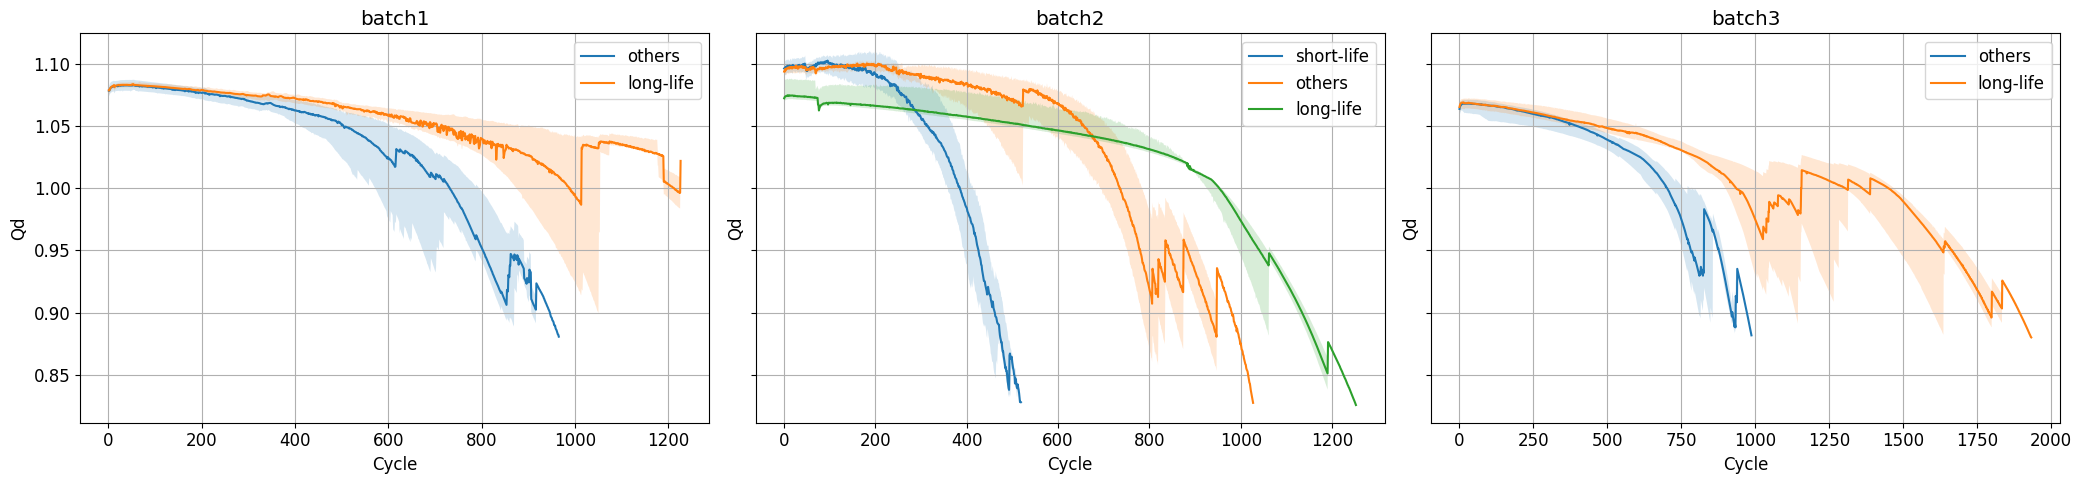

### Qd snapshot by batch/group/cycle

,batch_label,life_group,cycle_index,qd_median,qd_q25,qd_q75,n
0,batch1,long-life,10,1.082304,1.079876,1.083523,10
1,batch1,others,10,1.081914,1.077757,1.086144,36
2,batch1,long-life,50,1.083323,1.081142,1.085223,10
3,batch1,others,50,1.082621,1.078454,1.087077,36
4,batch1,long-life,100,1.081930,1.079992,1.084224,10
5,batch1,others,100,1.081215,1.076787,1.085006,36
6,batch1,long-life,300,1.074837,1.072172,1.077921,10
7,batch1,others,300,1.070306,1.064249,1.074536,36
8,batch2,long-life,10,1.074444,1.071622,1.087086,3
9,batch2,others,10,1.097077,1.091588,1.099352,8


## 4. Q2-2. 열화 속도는 일정한가, 아니면 가속되는가?


1–100, 101–300, 301+ 구간으로 나누어 retention 기준 drop per 100 cycles를 비교한다.


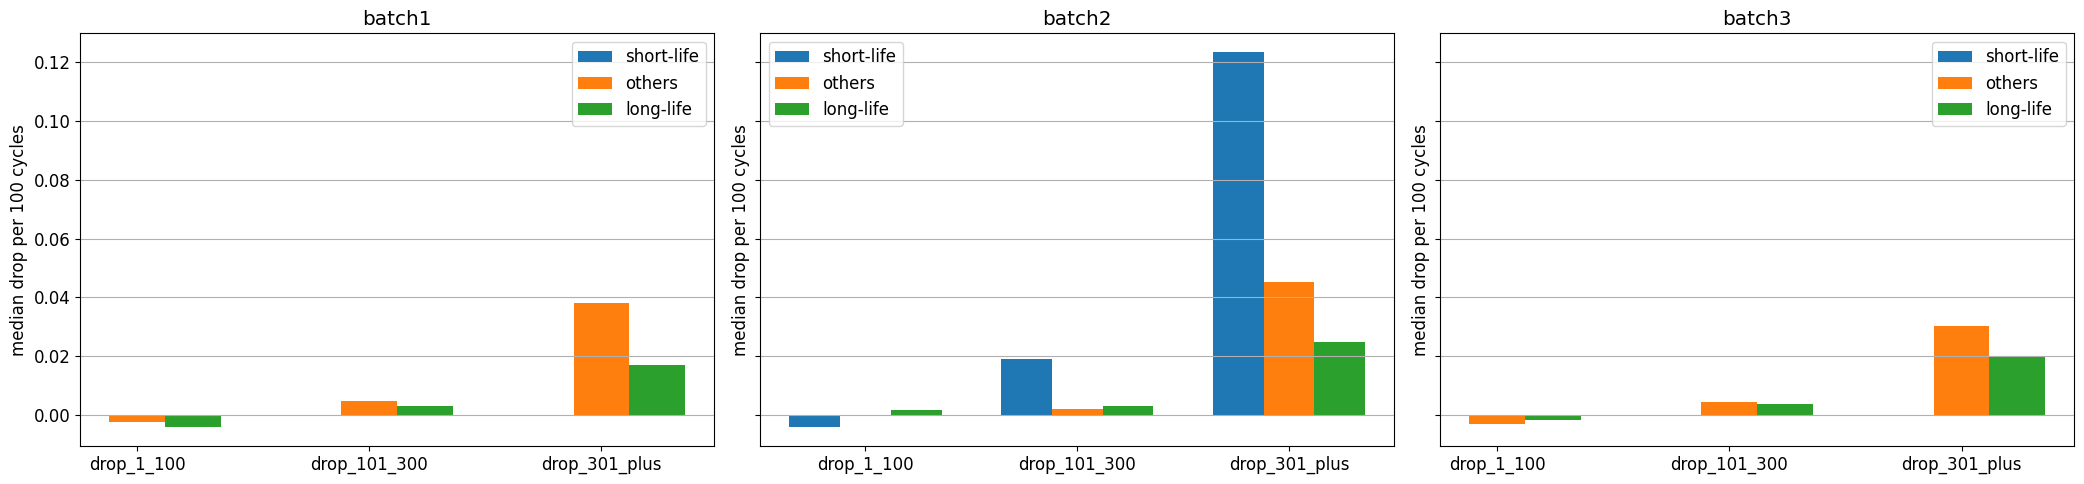

### Stage summary

,batch_label,life_group,stage,count,median,mean,std
0,batch1,long-life,drop_101_300,10,0.003149,0.003203,0.000557
1,batch1,long-life,drop_1_100,10,-0.004152,-0.003922,0.000972
2,batch1,long-life,drop_301_plus,10,0.016876,0.014965,0.009960
3,batch1,others,drop_101_300,36,0.004685,0.006081,0.004362
4,batch1,others,drop_1_100,36,-0.002263,-0.008298,0.037130
5,batch1,others,drop_301_plus,36,0.037949,0.050989,0.058138
6,batch2,long-life,drop_101_300,3,0.003008,0.002231,0.001907
7,batch2,long-life,drop_1_100,3,0.001830,0.001947,0.001435
8,batch2,long-life,drop_301_plus,3,0.024882,0.026924,0.005445
9,batch2,others,drop_101_300,8,0.002057,0.002518,0.005061


## 5. Q2 보강 해석: 고정 기준 그룹별 retention 비교


고정 cutoff 기준 그룹의 retention 곡선과 cycle 50, 100, 300 시점 retention snapshot을 함께 본다.


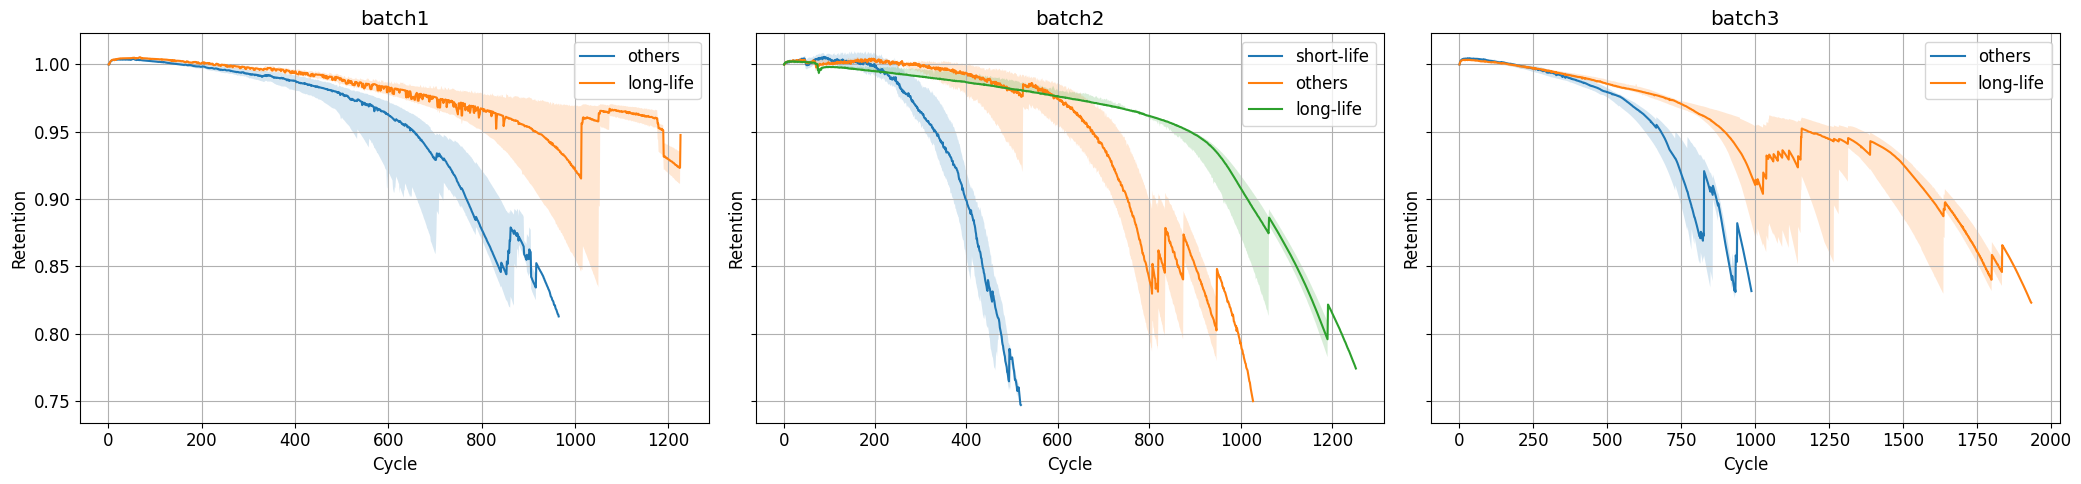

### Retention snapshot summary

,batch_label,life_group,cell_id_median,cell_id_mean,cell_id_count,Qd_retention_50_median,Qd_retention_50_mean,Qd_retention_50_count,Qd_retention_100_median,Qd_retention_100_mean,Qd_retention_100_count,Qd_retention_300_median,Qd_retention_300_mean,Qd_retention_300_count
0,batch1,long-life,4.5,11.200000,10,1.004731,1.004817,10,1.004111,1.003883,10,0.997827,0.997484,10
1,batch1,others,26.5,25.638889,36,1.003682,0.975883,36,1.002240,1.008215,36,0.993165,0.996077,36
2,batch2,long-life,32.0,32.666667,3,1.001732,1.001998,3,0.998188,0.998072,3,0.990956,0.993927,3
3,batch2,others,26.0,23.375000,8,1.000931,1.000960,8,1.000455,1.002010,8,0.999047,0.996743,8
4,batch2,short-life,16.5,16.285714,28,0.999746,0.999356,28,1.003865,1.003012,28,0.964464,0.969325,28
5,batch3,long-life,19.0,20.913043,23,1.003197,1.003096,23,1.001786,1.001702,23,0.995366,0.995101,23
6,batch3,others,23.0,22.142857,21,1.004341,1.002753,21,1.002915,1.000325,21,0.993866,0.987970,21


## 6. Q2 보조 해석: knee point는 얼마나 안정적인가?


knee point는 참고할 만한 전환점 후보지만, 이번 데이터에서는 모든 batch와 그룹에서 동일하게 안정적인 핵심 지표는 아니었다.  
따라서 여기서는 valid knee 비율과 knee ratio를 보조 근거로만 확인한다.


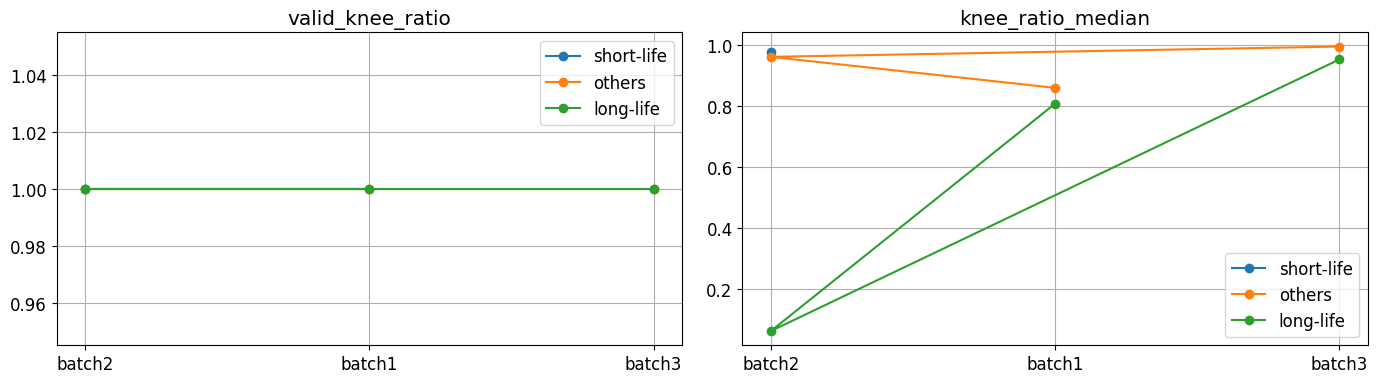

### Knee group summary

,batch_label,life_group,n,valid_knee_ratio,knee_ratio_median,knee_cycle_median
0,batch1,long-life,10,1.0,0.806996,893.5
1,batch1,others,36,1.0,0.858721,625.5
2,batch2,long-life,3,1.0,0.064081,73.0
3,batch2,others,8,1.0,0.960003,777.5
4,batch2,short-life,28,1.0,0.974230,419.5
5,batch3,long-life,23,1.0,0.951362,1013.0
6,batch3,others,21,1.0,0.993639,808.0


### Knee correlations

,batch_label,feature,spearman_with_cycle_life,n
0,batch1,knee_point,0.590557,46
1,batch1,knee_ratio,-0.131861,46
2,batch2,knee_point,0.328608,39
3,batch2,knee_ratio,-0.205689,39
4,batch3,knee_point,0.510272,44
5,batch3,knee_ratio,-0.244000,44


## 7. Q2-3. 가속 시작점 해석


이번 데이터에서는 단일 knee point보다 acceleration onset이 그룹 차이를 더 안정적으로 설명한다.

함께 보는 보조 지표:
- accel_onset_ratio
- cycle_to_99_retention
- cycle_to_95_retention
- cycle_to_90_retention


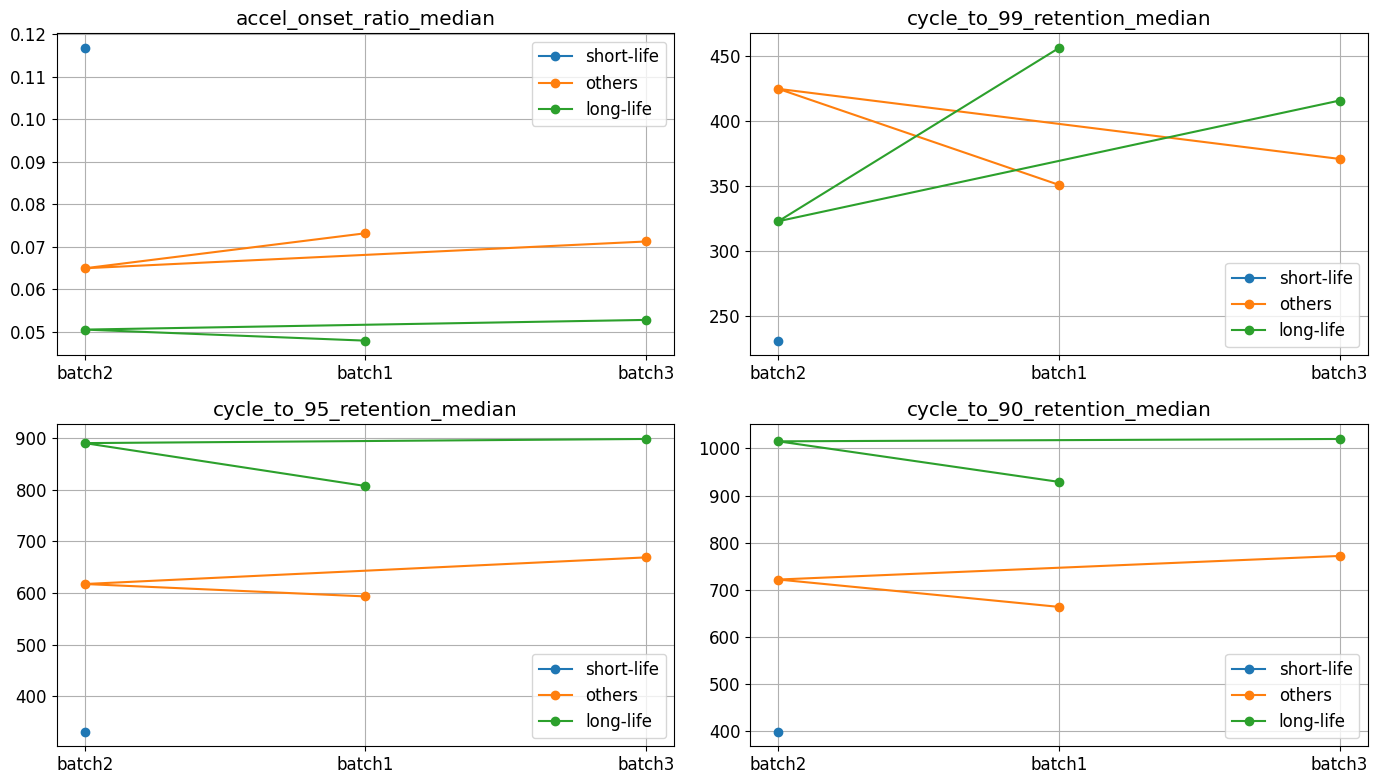

### Transition group summary

,batch_label,life_group,n,accel_onset_cycle_median,accel_onset_ratio_median,cycle_to_99_retention_median,cycle_to_95_retention_median,cycle_to_90_retention_median
0,batch1,long-life,10,52.5,0.047937,456.5,807.0,929.0
1,batch1,others,36,58.0,0.073190,351.0,593.5,664.0
2,batch2,long-life,3,53.0,0.050534,323.0,890.0,1015.0
3,batch2,others,8,51.5,0.064957,425.0,617.5,722.0
4,batch2,short-life,28,51.0,0.116764,231.0,332.0,399.5
5,batch3,long-life,23,60.0,0.052814,416.0,898.0,1020.0
6,batch3,others,21,60.0,0.071256,371.0,669.0,772.0


### Transition correlations

,batch_label,feature,spearman_with_cycle_life,n
0,batch1,cycle_to_90_retention,0.977551,42
1,batch1,cycle_to_95_retention,0.974815,43
2,batch1,cycle_to_99_retention,0.730438,46
3,batch1,accel_onset_ratio,-0.956951,46
4,batch2,cycle_to_90_retention,0.973066,39
5,batch2,cycle_to_95_retention,0.901939,39
6,batch2,cycle_to_99_retention,0.626645,39
7,batch2,accel_onset_ratio,-0.901508,39
8,batch3,cycle_to_90_retention,0.995736,44
9,batch3,cycle_to_95_retention,0.978679,44


## 8. Q2-4. 초기 열화 신호와 모델링 연결


초기 감소량, retention, slope를 포함해 batch별 상관 신호를 비교한다.


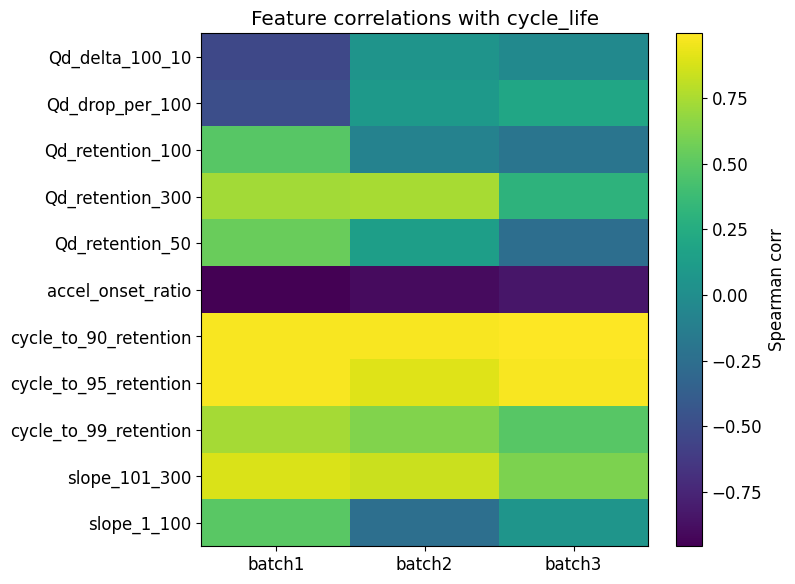

### Feature correlations

,batch_label,feature,spearman_with_cycle_life,n
0,batch1,cycle_to_90_retention,0.977551,42
1,batch1,cycle_to_95_retention,0.974815,43
2,batch1,slope_101_300,0.884791,46
3,batch1,cycle_to_99_retention,0.730438,46
4,batch1,Qd_retention_300,0.723387,46
5,batch1,Qd_retention_50,0.551869,46
6,batch1,slope_1_100,0.497780,46
7,batch1,Qd_retention_100,0.486431,46
8,batch1,Qd_drop_per_100,-0.486431,46
9,batch1,Qd_delta_100_10,-0.533921,46


In [23]:
group_order = ["short-life", "others", "long-life"]

# -----------------------------
# 3. Q2-1 사이클별 Qd 추이
# -----------------------------
display(Markdown("## 3. Q2-1. 사이클별 Qd 추이"))
display(Markdown(
"""
각 batch의 short-life / others / long-life 그룹별 Qd 중앙값 곡선과 사분위 범위를 비교한다.  
핵심은 세 batch 모두 감소 경향을 보이더라도, 감소 시작 시점과 곡선 간격이 batch마다 다르게 나타나는지 확인하는 것이다.
"""
))

if qd_group_summary.empty:
    display(Markdown("Qd 요약 데이터가 비어 있습니다. `_extract_cycle_qd()` 결과를 먼저 확인하세요."))
else:
    fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

    for ax, batch_label in zip(axes, ["batch1", "batch2", "batch3"]):
        sub = qd_group_summary[qd_group_summary["batch_label"] == batch_label]

        for g in group_order:
            sg = sub[sub["life_group"] == g].sort_values("cycle_index")
            if len(sg) == 0:
                continue

            ax.plot(sg["cycle_index"], sg["qd_median"], label=g)
            ax.fill_between(
                sg["cycle_index"],
                sg["qd_q25"],
                sg["qd_q75"],
                alpha=0.18
            )

        ax.set_title(batch_label)
        ax.set_xlabel("Cycle")
        ax.set_ylabel("Qd")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

curve_snapshot = (
    qd_group_summary[qd_group_summary["cycle_index"].isin([10, 50, 100, 300])]
    .sort_values(["batch_label", "cycle_index", "life_group"])
)
_display_group_table(curve_snapshot, "Qd snapshot by batch/group/cycle")


# -----------------------------
# 4. Q2-2 열화 속도 분석
# -----------------------------
display(Markdown("## 4. Q2-2. 열화 속도는 일정한가, 아니면 가속되는가?"))
display(Markdown(
"""
1–100, 101–300, 301+ 구간으로 나누어 retention 기준 drop per 100 cycles를 비교한다.
"""
))

required_cols = ["batch_label", "cell_id", "cycle_life", "life_group", "drop_1_100", "drop_101_300", "drop_301_plus"]

if feature_df.empty or not set(required_cols).issubset(feature_df.columns):
    display(Markdown("stage 분석용 feature_df가 비어 있거나 필수 컬럼이 없습니다."))
else:
    stage_long = feature_df[required_cols].melt(
        id_vars=["batch_label", "cell_id", "cycle_life", "life_group"],
        value_vars=["drop_1_100", "drop_101_300", "drop_301_plus"],
        var_name="stage",
        value_name="drop_per_100_cycles"
    )

    stage_summary = (
        stage_long.groupby(["batch_label", "life_group", "stage"])["drop_per_100_cycles"]
        .agg(["count", "median", "mean", "std"])
        .reset_index()
        .sort_values(["batch_label", "life_group", "stage"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
    stage_order = ["drop_1_100", "drop_101_300", "drop_301_plus"]

    for ax, batch_label in zip(axes, ["batch1", "batch2", "batch3"]):
        sub = stage_summary[stage_summary["batch_label"] == batch_label]
        x = np.arange(len(stage_order))
        width = 0.24

        for j, g in enumerate(group_order):
            sg = sub[sub["life_group"] == g].set_index("stage").reindex(stage_order)
            ax.bar(x + (j - 1) * width, sg["median"], width=width, label=g)

        ax.set_xticks(x)
        ax.set_xticklabels(stage_order)
        ax.set_title(batch_label)
        ax.set_ylabel("median drop per 100 cycles")
        ax.grid(True, axis="y")
        ax.legend()

    plt.tight_layout()
    plt.show()

    _display_group_table(stage_summary, "Stage summary")


# -----------------------------
# 5. retention 비교
# -----------------------------
display(Markdown("## 5. Q2 보강 해석: 고정 기준 그룹별 retention 비교"))
display(Markdown(
"""
고정 cutoff 기준 그룹의 retention 곡선과 cycle 50, 100, 300 시점 retention snapshot을 함께 본다.
"""
))

if qd_filtered_df.empty:
    display(Markdown("retention 계산용 Qd 데이터가 없습니다."))
else:
    ret_curve_df = qd_filtered_df.copy()

    first_qd = (
        ret_curve_df.groupby(["batch_label", "cell_id"])["Qd"]
        .first()
        .rename("Qd0")
        .reset_index()
    )

    ret_curve_df = ret_curve_df.merge(first_qd, on=["batch_label", "cell_id"], how="left")
    ret_curve_df["retention"] = ret_curve_df["Qd"] / ret_curve_df["Qd0"]

    ret_group_summary = (
        ret_curve_df.dropna(subset=["retention"])
        .groupby(["batch_label", "life_group", "cycle_index"])["retention"]
        .agg(
            retention_median="median",
            retention_q25=lambda x: np.nanpercentile(x, 25),
            retention_q75=lambda x: np.nanpercentile(x, 75),
            n="count"
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

    for ax, batch_label in zip(axes, ["batch1", "batch2", "batch3"]):
        sub = ret_group_summary[ret_group_summary["batch_label"] == batch_label]

        for g in group_order:
            sg = sub[sub["life_group"] == g].sort_values("cycle_index")
            if len(sg) == 0:
                continue

            ax.plot(sg["cycle_index"], sg["retention_median"], label=g)
            ax.fill_between(sg["cycle_index"], sg["retention_q25"], sg["retention_q75"], alpha=0.18)

        ax.set_title(batch_label)
        ax.set_xlabel("Cycle")
        ax.set_ylabel("Retention")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

if feature_df.empty:
    display(Markdown("retention snapshot용 feature_df가 없습니다."))
else:
    retention_snapshot = (
        feature_df[
            ["batch_label", "cell_id", "life_group", "Qd_retention_50", "Qd_retention_100", "Qd_retention_300"]
        ]
        .groupby(["batch_label", "life_group"])
        .agg(["median", "mean", "count"])
    )
    retention_snapshot.columns = ["_".join(col).strip("_") for col in retention_snapshot.columns]
    retention_snapshot = retention_snapshot.reset_index().sort_values(["batch_label", "life_group"])

    _display_group_table(retention_snapshot, "Retention snapshot summary")


# -----------------------------
# 6. knee point
# -----------------------------
display(Markdown("## 6. Q2 보조 해석: knee point는 얼마나 안정적인가?"))
display(Markdown(
"""
knee point는 참고할 만한 전환점 후보지만, 이번 데이터에서는 모든 batch와 그룹에서 동일하게 안정적인 핵심 지표는 아니었다.  
따라서 여기서는 valid knee 비율과 knee ratio를 보조 근거로만 확인한다.
"""
))

if feature_df.empty:
    display(Markdown("knee 분석용 feature_df가 없습니다."))
else:
    knee_group_summary = (
        feature_df.groupby(["batch_label", "life_group"])
        .agg(
            n=("cell_id", "count"),
            valid_knee_ratio=("valid_knee", "mean"),
            knee_ratio_median=("knee_ratio", "median"),
            knee_cycle_median=("knee_point", "median"),
        )
        .reset_index()
        .sort_values(["batch_label", "life_group"])
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for i, metric in enumerate(["valid_knee_ratio", "knee_ratio_median"]):
        ax = axes[i]
        for g in group_order:
            sg = knee_group_summary[knee_group_summary["life_group"] == g]
            ax.plot(sg["batch_label"], sg[metric], marker="o", label=g)
        ax.set_title(metric)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

    _display_group_table(knee_group_summary, "Knee group summary")

    knee_correlations = _spearman_series(
        feature_df,
        ["knee_point", "knee_ratio"],
        target_col="cycle_life"
    ).sort_values(["batch_label", "spearman_with_cycle_life"], ascending=[True, False])

    _display_group_table(knee_correlations, "Knee correlations")


# -----------------------------
# 7. acceleration onset
# -----------------------------
display(Markdown("## 7. Q2-3. 가속 시작점 해석"))
display(Markdown(
"""
이번 데이터에서는 단일 knee point보다 acceleration onset이 그룹 차이를 더 안정적으로 설명한다.

함께 보는 보조 지표:
- accel_onset_ratio
- cycle_to_99_retention
- cycle_to_95_retention
- cycle_to_90_retention
"""
))

if feature_df.empty:
    display(Markdown("transition 분석용 feature_df가 없습니다."))
else:
    transition_group_summary = (
        feature_df.groupby(["batch_label", "life_group"])
        .agg(
            n=("cell_id", "count"),
            accel_onset_cycle_median=("accel_onset_cycle", "median"),
            accel_onset_ratio_median=("accel_onset_ratio", "median"),
            cycle_to_99_retention_median=("cycle_to_99_retention", "median"),
            cycle_to_95_retention_median=("cycle_to_95_retention", "median"),
            cycle_to_90_retention_median=("cycle_to_90_retention", "median"),
        )
        .reset_index()
        .sort_values(["batch_label", "life_group"])
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    metrics = [
        "accel_onset_ratio_median",
        "cycle_to_99_retention_median",
        "cycle_to_95_retention_median",
        "cycle_to_90_retention_median",
    ]

    for ax, metric in zip(axes.flatten(), metrics):
        for g in group_order:
            sg = transition_group_summary[transition_group_summary["life_group"] == g]
            ax.plot(sg["batch_label"], sg[metric], marker="o", label=g)
        ax.set_title(metric)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

    _display_group_table(transition_group_summary, "Transition group summary")

    transition_correlations = _spearman_series(
        feature_df,
        [
            "accel_onset_ratio",
            "cycle_to_99_retention",
            "cycle_to_95_retention",
            "cycle_to_90_retention",
        ],
        target_col="cycle_life"
    ).sort_values(["batch_label", "spearman_with_cycle_life"], ascending=[True, False])

    _display_group_table(transition_correlations, "Transition correlations")


# -----------------------------
# 8. feature correlations
# -----------------------------
display(Markdown("## 8. Q2-4. 초기 열화 신호와 모델링 연결"))
display(Markdown(
"""
초기 감소량, retention, slope를 포함해 batch별 상관 신호를 비교한다.
"""
))

if feature_df.empty:
    display(Markdown("feature correlation 계산용 feature_df가 없습니다."))
else:
    feature_cols = [
        "Qd_delta_100_10",
        "Qd_retention_50",
        "Qd_retention_100",
        "Qd_retention_300",
        "Qd_drop_per_100",
        "slope_1_100",
        "slope_101_300",
        "accel_onset_ratio",
        "cycle_to_99_retention",
        "cycle_to_95_retention",
        "cycle_to_90_retention",
    ]

    feature_correlations = _spearman_series(
        feature_df,
        feature_cols,
        target_col="cycle_life"
    ).sort_values(["batch_label", "spearman_with_cycle_life"], ascending=[True, False])

    pivot_corr = feature_correlations.pivot(index="feature", columns="batch_label", values="spearman_with_cycle_life")

    plt.figure(figsize=(8, max(6, len(pivot_corr) * 0.45)))
    plt.imshow(pivot_corr.fillna(0), aspect="auto")
    plt.xticks(range(len(pivot_corr.columns)), pivot_corr.columns)
    plt.yticks(range(len(pivot_corr.index)), pivot_corr.index)
    plt.colorbar(label="Spearman corr")
    plt.title("Feature correlations with cycle_life")
    plt.tight_layout()
    plt.show()

    _display_group_table(feature_correlations, "Feature correlations")

### 3. ΔQ(V)곡선 - 초기 사이클에서 차이가 보이는가?

- cycle 100 - cycle 10
- long-life vs short-life 비교
- 통계 feature 추출

In [34]:
BATCHES = {
    "batch1": batch1,
    "batch2": batch2,
    "batch3": batch3,
}

V_grid = np.linspace(2.0, 3.6, 1000)

In [35]:
# -----------------------------
# helper
# -----------------------------
def to_list_of_dicts(x):
    if isinstance(x, list):
        return x
    if isinstance(x, dict):
        keys = list(x.keys())
        if len(keys) == 0:
            return []
        n = min(len(x[k]) for k in keys)
        return [{k: x[k][i] for k in keys} for i in range(n)]
    return []


def to_scalar(x):
    try:
        arr = np.asarray(x, dtype=float).reshape(-1)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan


def extract_deltaq_features(delta_q, v_grid):
    return {
        "deltaQ_min": float(np.min(delta_q)),
        "deltaQ_max": float(np.max(delta_q)),
        "deltaQ_mean": float(np.mean(delta_q)),
        "deltaQ_std": float(np.std(delta_q)),
        "deltaQ_area": float(np.trapezoid(delta_q, v_grid)),
        "deltaQ_abs_area": float(np.trapezoid(np.abs(delta_q), v_grid)),
        "deltaQ_argmin_v": float(v_grid[np.argmin(delta_q)]),
        "deltaQ_argmax_v": float(v_grid[np.argmax(delta_q)]),
    }


In [36]:
# -----------------------------
# build records
# -----------------------------
records = []
deltaq_curves = {}

for batch_label, batch in BATCHES.items():
    for cell_id, cell in enumerate(batch):
        try:
            cycles = to_list_of_dicts(cell.get("cycles"))

            if len(cycles) < 100:
                continue

            q10 = cycles[9].get("Qdlin")
            q100 = cycles[99].get("Qdlin")

            if q10 is None or q100 is None:
                continue

            q10 = np.asarray(q10, dtype=float).reshape(-1)
            q100 = np.asarray(q100, dtype=float).reshape(-1)

            if q10.shape != (1000,) or q100.shape != (1000,):
                continue
            if not (np.all(np.isfinite(q10)) and np.all(np.isfinite(q100))):
                continue

            delta_q = q100 - q10
            cycle_life = to_scalar(cell.get("cycle_life"))
            if not np.isfinite(cycle_life):
                continue

            cycle_life = int(cycle_life)
            charging_policy = str(cell.get("policy_readable") or cell.get("policy") or "unknown")

            row = {
                "batch_label": batch_label,
                "cell_id": cell_id,
                "cell_key": f"{batch_label}_{cell_id}",
                "cycle_life": cycle_life,
                "charging_policy": charging_policy,
            }
            row.update(extract_deltaq_features(delta_q, V_grid))

            records.append(row)
            deltaq_curves[f"{batch_label}_{cell_id}"] = delta_q

        except Exception as e:
            print(f"{batch_label} cell {cell_id} 처리 실패: {e}")


In [37]:
deltaq_feature_df = pd.DataFrame(records)

print("유효 cell 수:", len(deltaq_feature_df))
print(deltaq_feature_df.shape)
display(deltaq_feature_df.head())

if deltaq_feature_df.empty:
    raise ValueError("유효한 ΔQ(V) 데이터가 없습니다. cycles/Qdlin 구조를 다시 확인하세요.")

유효 cell 수: 129
(129, 13)


,batch_label,cell_id,cell_key,cycle_life,charging_policy,deltaQ_min,deltaQ_max,deltaQ_mean,deltaQ_std,deltaQ_area,deltaQ_abs_area,deltaQ_argmin_v,deltaQ_argmax_v
0,batch1,0,batch1_0,1190,3.6C(80%)-3.6C,-0.008460,0.000768,-0.002873,0.003109,-0.004603,0.004733,2.464464,3.600000
1,batch1,1,batch1_1,1179,3.6C(80%)-3.6C,-0.011004,-0.000088,-0.004100,0.003112,-0.006565,0.006565,2.387588,2.022422
2,batch1,2,batch1_2,1177,3.6C(80%)-3.6C,-0.017216,0.000013,-0.004487,0.004281,-0.007185,0.007186,2.369970,2.019219
3,batch1,3,batch1_3,1226,4C(80%)-4C,-0.018961,0.000182,-0.007456,0.006007,-0.011940,0.011959,2.578178,2.000000
4,batch1,4,batch1_4,1227,4C(80%)-4C,-0.013958,0.000046,-0.005750,0.004744,-0.009209,0.009211,2.663063,2.004805


In [42]:
# -----------------------------
# 그룹 라벨
# -----------------------------
# 전체 기준 2그룹
global_median = feature_df["cycle_life"].median()
feature_df["life_group_2"] = np.where(
    feature_df["cycle_life"] >= global_median,
    "long_life",
    "short_life"
)

# 전체 기준 3그룹 (tertile)
q1 = feature_df["cycle_life"].quantile(1/3)
q2 = feature_df["cycle_life"].quantile(2/3)
feature_df["life_group_3"] = pd.cut(
    feature_df["cycle_life"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["low", "mid", "high"]
)

print("global median cycle_life:", round(global_median, 2))
print("2-group counts")
print(feature_df["life_group_2"].value_counts())
print("\n3-group counts")
print(feature_df["life_group_3"].value_counts(dropna=False))


global median cycle_life: 828.0
2-group counts
life_group_2
long_life     66
short_life    63
Name: count, dtype: int64

3-group counts
life_group_3
low     43
mid     43
high    43
Name: count, dtype: int64


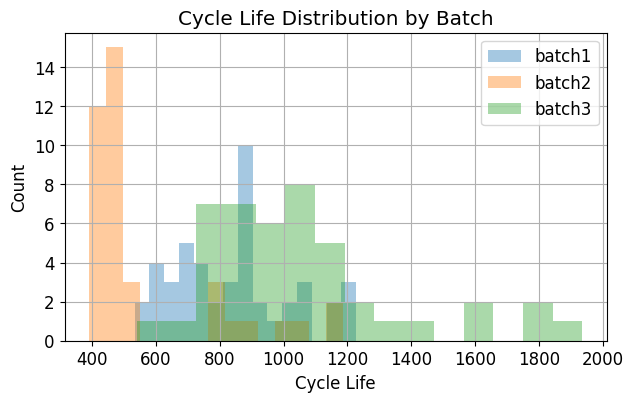

In [44]:
# -----------------------------
# 1) batch별 cycle_life 분포
# -----------------------------
plt.figure(figsize=(7, 4))
for b in ["batch1", "batch2", "batch3"]:
    x = feature_df.loc[feature_df["batch_label"] == b, "cycle_life"]
    plt.hist(x, bins=15, alpha=0.4, label=b)
plt.xlabel("Cycle Life")
plt.ylabel("Count")
plt.title("Cycle Life Distribution by Batch")
plt.legend()
plt.grid()
plt.show()

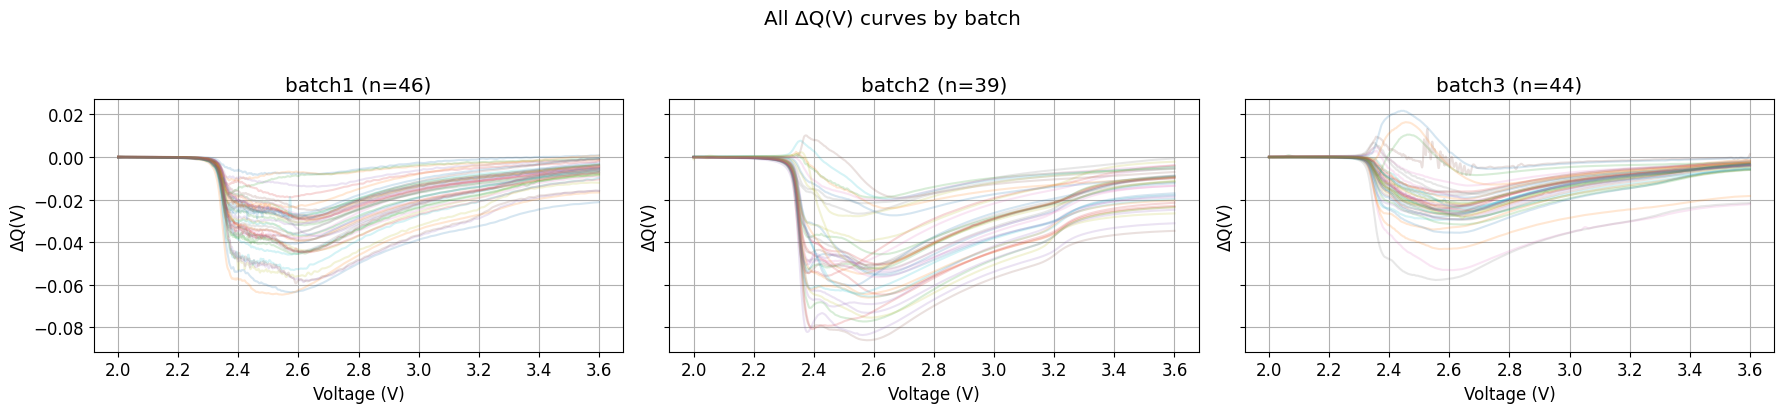

In [45]:
# -----------------------------
# 2) batch별 모든 ΔQ(V) 곡선
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    ids = feature_df.loc[feature_df["batch_label"] == b, "cell_key"].tolist()
    for cid in ids:
        ax.plot(V_grid, deltaq_curves[cid], alpha=0.18)
    ax.set_title(f"{b} (n={len(ids)})")
    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("ΔQ(V)")
    ax.grid()

plt.suptitle("All ΔQ(V) curves by batch", y=1.03)
plt.tight_layout()
plt.show()

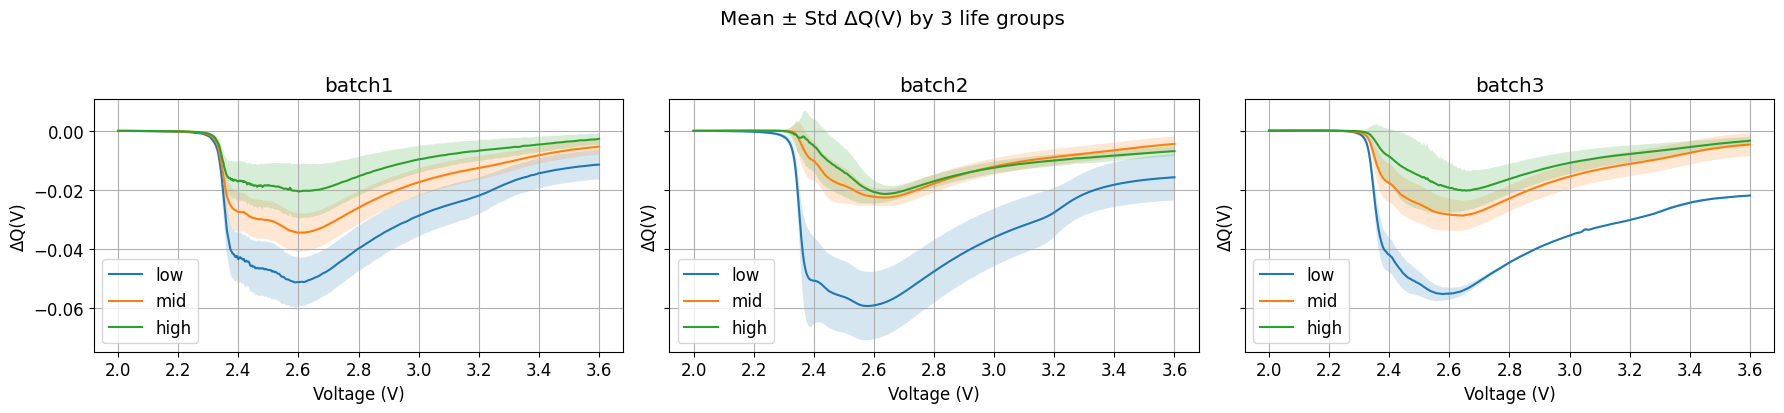

In [46]:
# -----------------------------
# 3) batch별 3그룹 평균 ΔQ(V)
# -----------------------------
group_order_3 = ["low", "mid", "high"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = feature_df[feature_df["batch_label"] == b]

    for g in group_order_3:
        ids = sub.loc[sub["life_group_3"] == g, "cell_key"].tolist()
        if len(ids) == 0:
            continue

        mat = np.vstack([deltaq_curves[cid] for cid in ids])
        mean_curve = mat.mean(axis=0)
        std_curve = mat.std(axis=0)

        ax.plot(V_grid, mean_curve, label=g)
        ax.fill_between(V_grid, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)

    ax.set_title(b)
    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("ΔQ(V)")
    ax.grid()
    ax.legend()

plt.suptitle("Mean ± Std ΔQ(V) by 3 life groups", y=1.03)
plt.tight_layout()
plt.show()


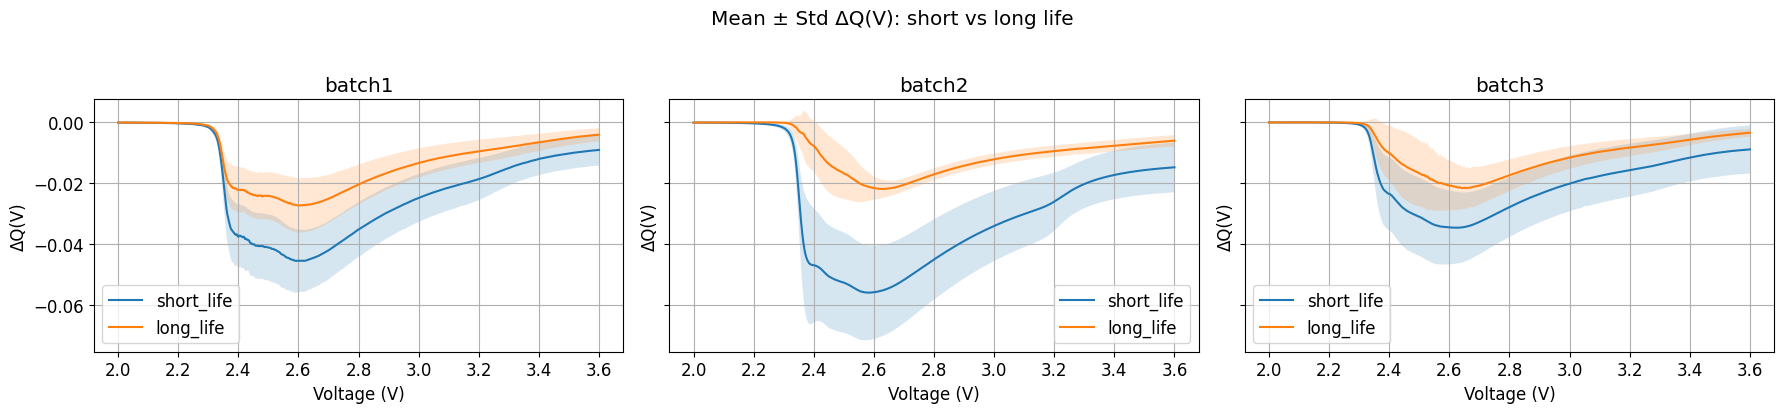

In [47]:
# -----------------------------
# 4) batch별 long vs short 평균 ΔQ(V)
# -----------------------------
group_order_2 = ["short_life", "long_life"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = feature_df[feature_df["batch_label"] == b]

    for g in group_order_2:
        ids = sub.loc[sub["life_group_2"] == g, "cell_key"].tolist()
        if len(ids) == 0:
            continue

        mat = np.vstack([deltaq_curves[cid] for cid in ids])
        mean_curve = mat.mean(axis=0)
        std_curve = mat.std(axis=0)

        ax.plot(V_grid, mean_curve, label=g)
        ax.fill_between(V_grid, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)

    ax.set_title(b)
    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("ΔQ(V)")
    ax.grid()
    ax.legend()

plt.suptitle("Mean ± Std ΔQ(V): short vs long life", y=1.03)
plt.tight_layout()
plt.show()

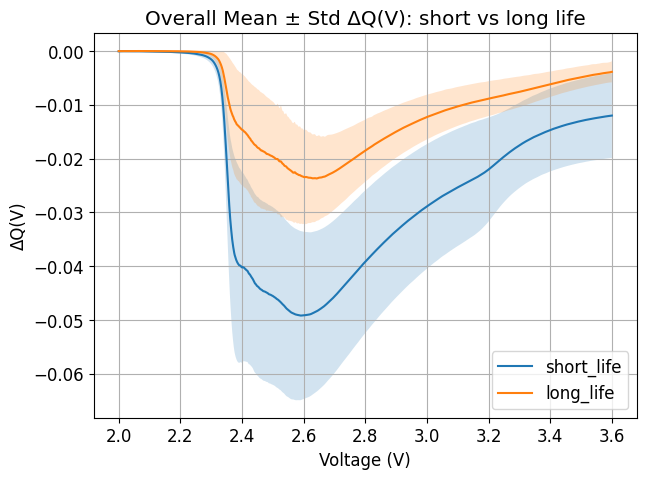

In [48]:
# -----------------------------
# 5) 전체 short vs long 평균 곡선
# -----------------------------
plt.figure(figsize=(7, 5))

for g in group_order_2:
    ids = feature_df.loc[feature_df["life_group_2"] == g, "cell_key"].tolist()
    if len(ids) == 0:
        continue

    mat = np.vstack([deltaq_curves[cid] for cid in ids])
    mean_curve = mat.mean(axis=0)
    std_curve = mat.std(axis=0)

    plt.plot(V_grid, mean_curve, label=g)
    plt.fill_between(V_grid, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

plt.xlabel("Voltage (V)")
plt.ylabel("ΔQ(V)")
plt.title("Overall Mean ± Std ΔQ(V): short vs long life")
plt.legend()
plt.grid()
plt.show()


In [50]:
# -----------------------------
# 6) feature 요약
# -----------------------------
display(feature_df.describe().round(4))

,cell_id,cycle_life,deltaQ_min,deltaQ_max,deltaQ_mean,deltaQ_std,deltaQ_area,deltaQ_abs_area,deltaQ_argmin_v,deltaQ_argmax_v
count,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000
mean,21.1008,833.6899,-0.0371,0.0008,-0.0170,0.0123,-0.0272,0.0274,2.5948,2.1060
std,12.6280,314.9727,0.0178,0.0031,0.0097,0.0059,0.0155,0.0153,0.0686,0.2263
min,0.0000,392.0000,-0.0862,-0.0002,-0.0465,0.0028,-0.0744,0.0035,2.3636,2.0000
25%,10.0000,559.0000,-0.0526,-0.0001,-0.0236,0.0081,-0.0378,0.0166,2.5686,2.0000
50%,21.0000,828.0000,-0.0300,0.0000,-0.0134,0.0100,-0.0214,0.0214,2.6086,2.0208
75%,32.0000,1017.0000,-0.0242,0.0001,-0.0103,0.0175,-0.0166,0.0378,2.6342,2.1554
max,45.0000,1935.0000,-0.0056,0.0217,0.0008,0.0286,0.0013,0.0744,2.7351,3.6000


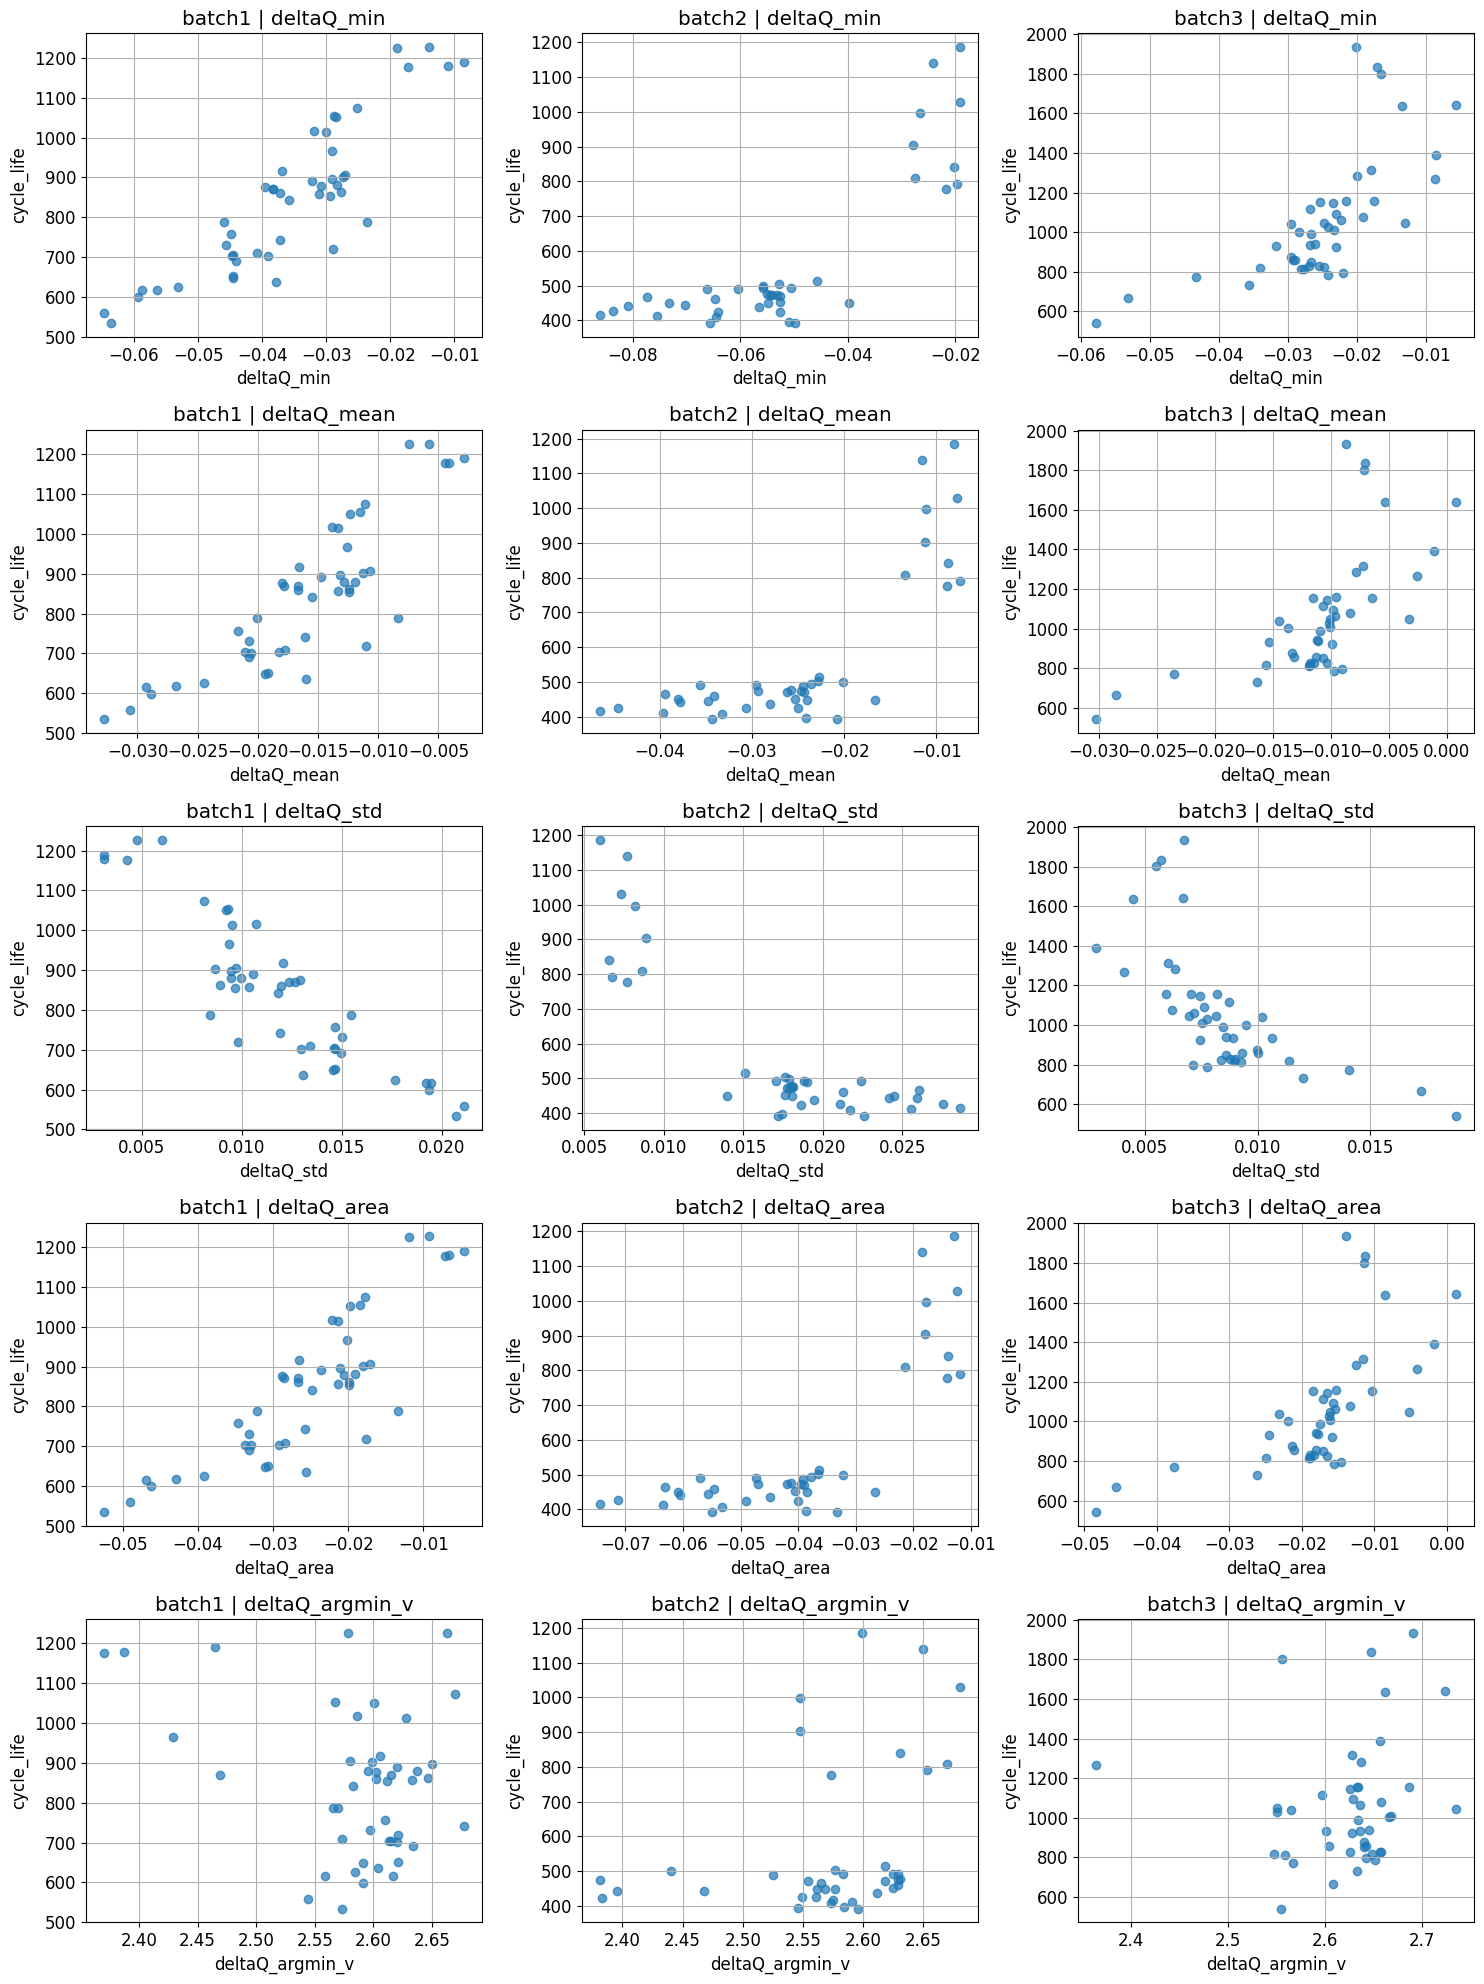

In [52]:
# -----------------------------
# 7) 주요 feature 산점도
# -----------------------------
selected_features = ["deltaQ_min", "deltaQ_mean", "deltaQ_std", "deltaQ_area", "deltaQ_argmin_v"]

fig, axes = plt.subplots(len(selected_features), 3, figsize=(15, 4 * len(selected_features)))
for i, col in enumerate(selected_features):
    for j, b in enumerate(["batch1", "batch2", "batch3"]):
        ax = axes[i, j] if len(selected_features) > 1 else axes[j]
        sub = feature_df[feature_df["batch_label"] == b]
        ax.scatter(sub[col], sub["cycle_life"], alpha=0.7)
        ax.set_title(f"{b} | {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("cycle_life")
        ax.grid()

plt.tight_layout()
plt.show()

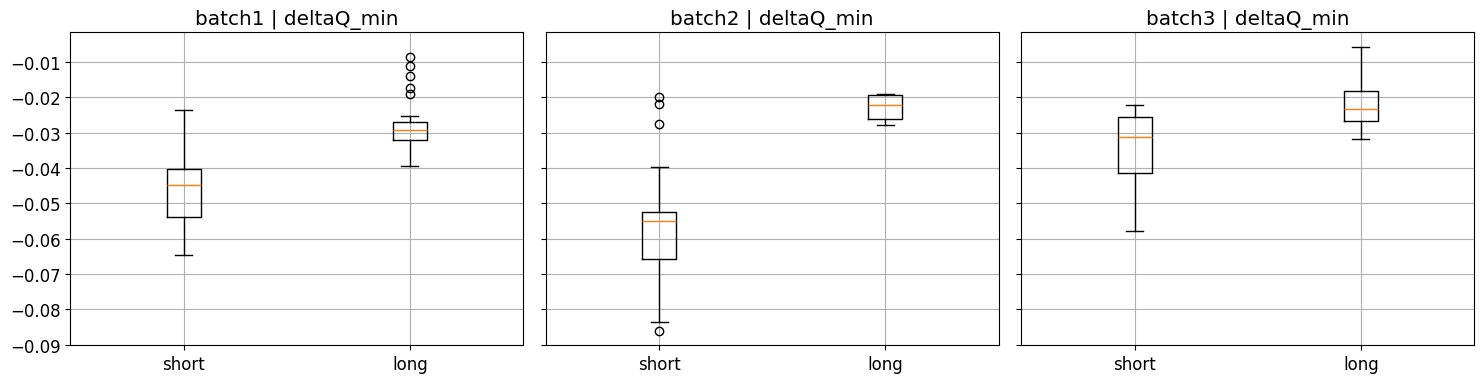

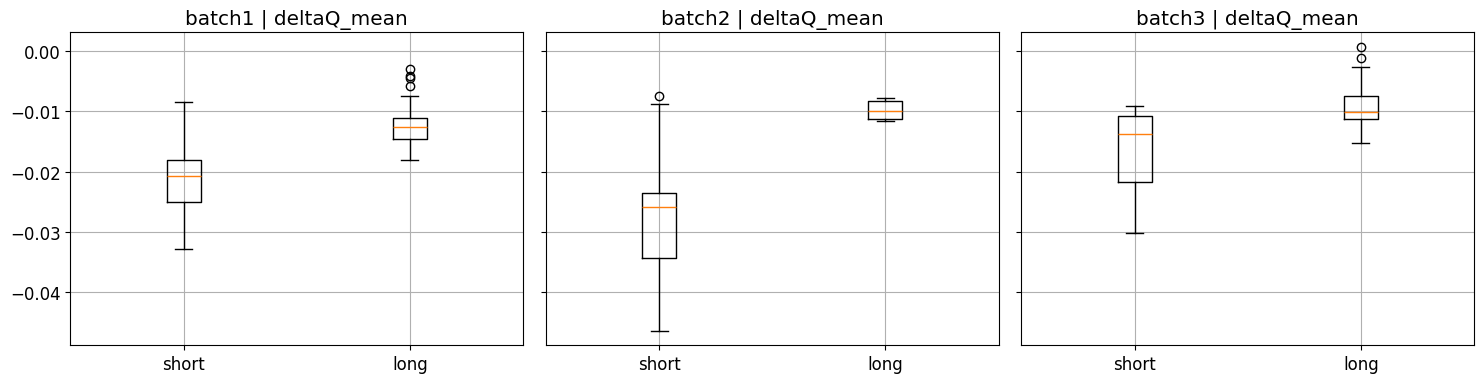

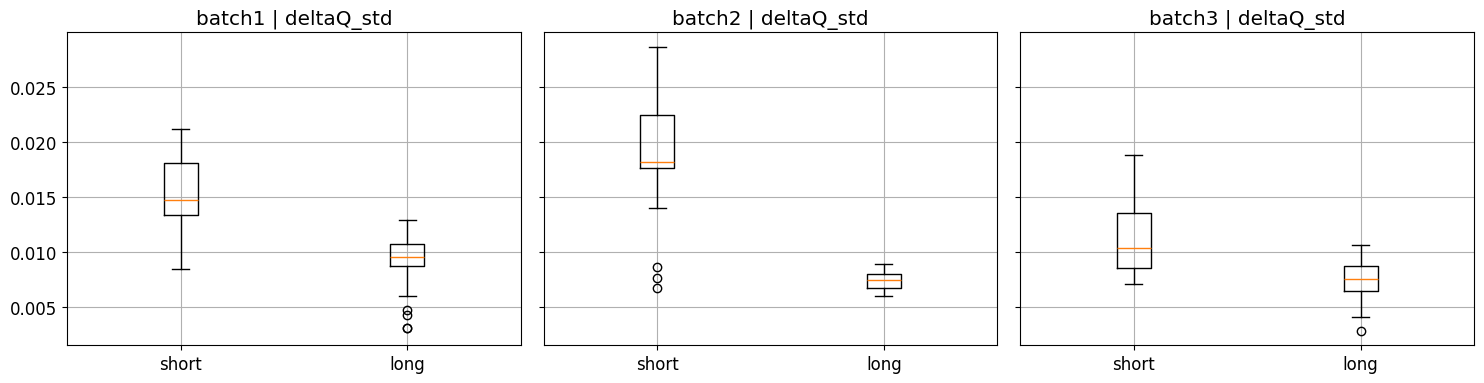

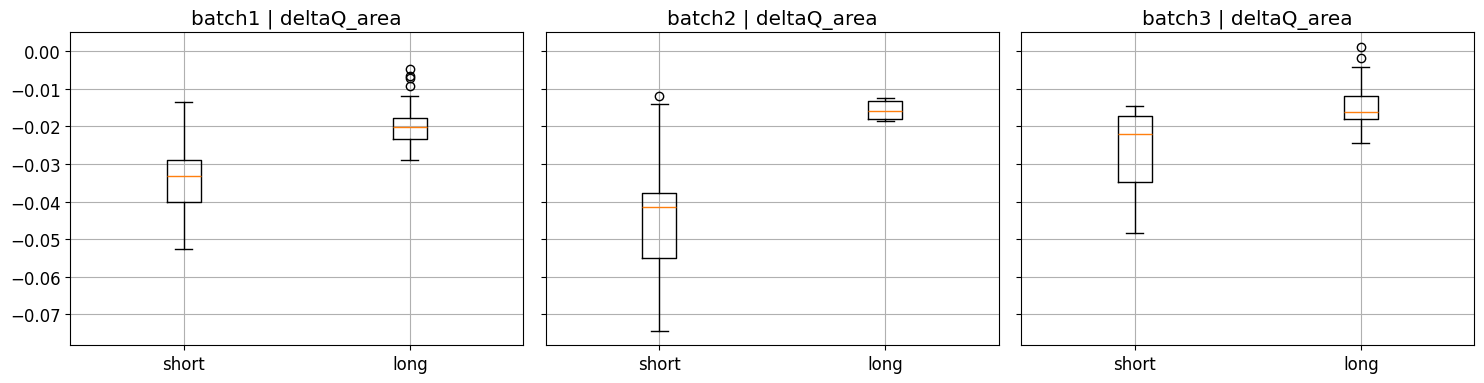

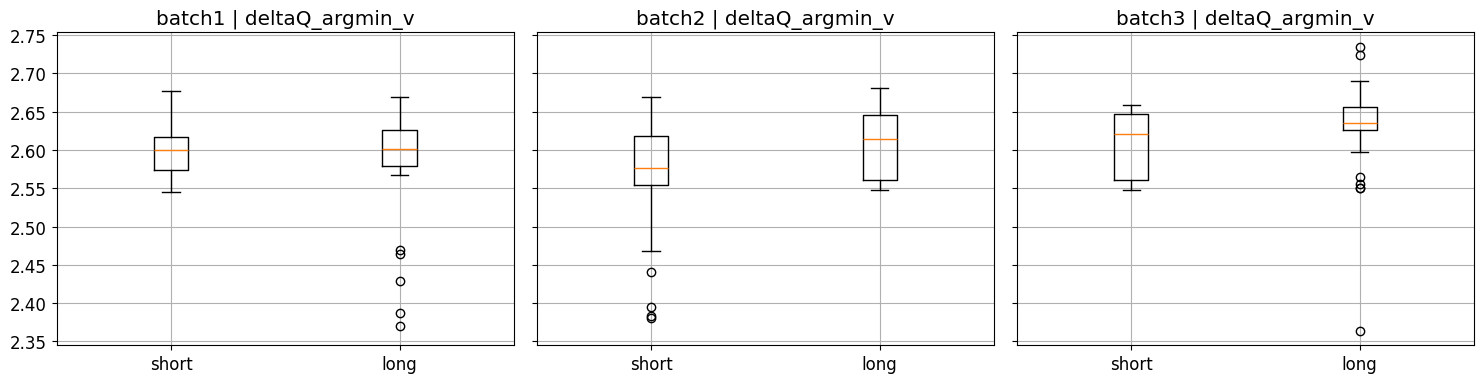

In [53]:
# -----------------------------
# 8) 주요 feature boxplot (batch별)
# -----------------------------
for col in selected_features:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
        sub = feature_df[feature_df["batch_label"] == b]
        data_short = sub.loc[sub["life_group_2"] == "short_life", col].dropna()
        data_long = sub.loc[sub["life_group_2"] == "long_life", col].dropna()

        ax.boxplot([data_short, data_long], labels=["short", "long"])
        ax.set_title(f"{b} | {col}")
        ax.grid()

    plt.tight_layout()
    plt.show()

### 4. 충전 조건 (C-rate)과 수명의 관계는?
    - 충전 프로토콜별 평균 수명 비교
    - 고속 충전 셀이 정말 수명이 짧은가?
    - 충전 전류 패턴과 열화 속도 상관 분석

In [ ]:
# -----------------------------
# helper
# -----------------------------
def parse_policy(policy):
    policy = str(policy)

    first = pd.to_numeric(
        pd.Series(policy).str.extract(r'^(\d+(?:[._]\d+)?)C', expand=False).str.replace('_', '.', regex=False),
        errors="coerce"
    ).iloc[0]

    soc = pd.to_numeric(
        pd.Series(policy).str.extract(r'(\d+)(?:PER|%)', expand=False),
        errors="coerce"
    ).iloc[0]

    second = pd.to_numeric(
        pd.Series(policy).str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C', expand=False).str.replace('_', '.', regex=False),
        errors="coerce"
    ).iloc[0]

    return first, soc, second

def get_early_degradation(cell):
    try:
        summary = cell.get("summary", {})
        qd = summary.get("QDischarge", summary.get("Qd", []))
        qd = np.asarray(qd, dtype=float).reshape(-1)
        qd = qd[np.isfinite(qd)]
        if len(qd) >= 100:
            return float(qd[1] - qd[99])   # cycle 2 - cycle 100
        return np.nan
    except Exception:
        return np.nan

In [55]:
# -----------------------------
# build dataframe
# -----------------------------
rows = []

for batch_label, batch in BATCHES.items():
    for cell_id, cell in enumerate(batch):
        cycle_life = to_scalar(cell.get("cycle_life"))
        if not np.isfinite(cycle_life):
            continue

        policy = cell.get("policy_readable", cell.get("policy", "unknown"))
        if isinstance(policy, (list, np.ndarray)):
            policy = str(np.asarray(policy).reshape(-1)[0])
        else:
            policy = str(policy)

        first_c_rate, soc_percent, second_c_rate = parse_policy(policy)

        rows.append({
            "batch_label": batch_label,
            "cell_id": cell_id,
            "cell_key": f"{batch_label}_{cell_id}",
            "policy_readable": policy,
            "cycle_life": float(cycle_life),
            "first_c_rate": first_c_rate,
            "soc_percent": soc_percent,
            "second_c_rate": second_c_rate,
            "speed_gap": first_c_rate - second_c_rate if pd.notna(first_c_rate) and pd.notna(second_c_rate) else np.nan,
            "early_degradation_100": get_early_degradation(cell),
        })

df = pd.DataFrame(rows)

print("유효 cell 수:", len(df))
display(df.head())

if df.empty:
    raise ValueError("유효한 충전 조건 데이터가 없습니다.")


유효 cell 수: 129


,batch_label,cell_id,cell_key,policy_readable,cycle_life,first_c_rate,soc_percent,second_c_rate,speed_gap,early_degradation_100
0,batch1,0,batch1_0,3.6C(80%)-3.6C,1190.0,3.6,80,3.6,0.0,-0.005223
1,batch1,1,batch1_1,3.6C(80%)-3.6C,1179.0,3.6,80,3.6,0.0,-0.005329
2,batch1,2,batch1_2,3.6C(80%)-3.6C,1177.0,3.6,80,3.6,0.0,-0.005018
3,batch1,3,batch1_3,4C(80%)-4C,1226.0,4.0,80,4.0,0.0,-0.005027
4,batch1,4,batch1_4,4C(80%)-4C,1227.0,4.0,80,4.0,0.0,-0.004229


,batch_label,policy_readable,count,mean,median,std
3,batch1,4C(80%)-4C,2,1226.500000,1226.5,0.707107
0,batch1,3.6C(80%)-3.6C,3,1182.000000,1179.0,7.000000
1,batch1,4.4C(80%)-4.4C,1,1074.000000,1074.0,NaN
20,batch1,8C(15%)-3.6C,2,1008.500000,1008.5,60.104076
4,batch1,5.4C(40%)-3.6C,2,966.500000,966.5,123.743687
11,batch1,6C(30%)-3.6C,2,952.500000,952.5,86.974134
13,batch1,6C(40%)-3C,2,935.500000,935.5,115.258405
5,batch1,5.4C(50%)-3.6C,2,899.500000,899.5,3.535534
15,batch1,6C(50%)-3C,2,888.500000,888.5,40.305087
7,batch1,5.4C(60%)-3.6C,2,859.500000,859.5,3.535534


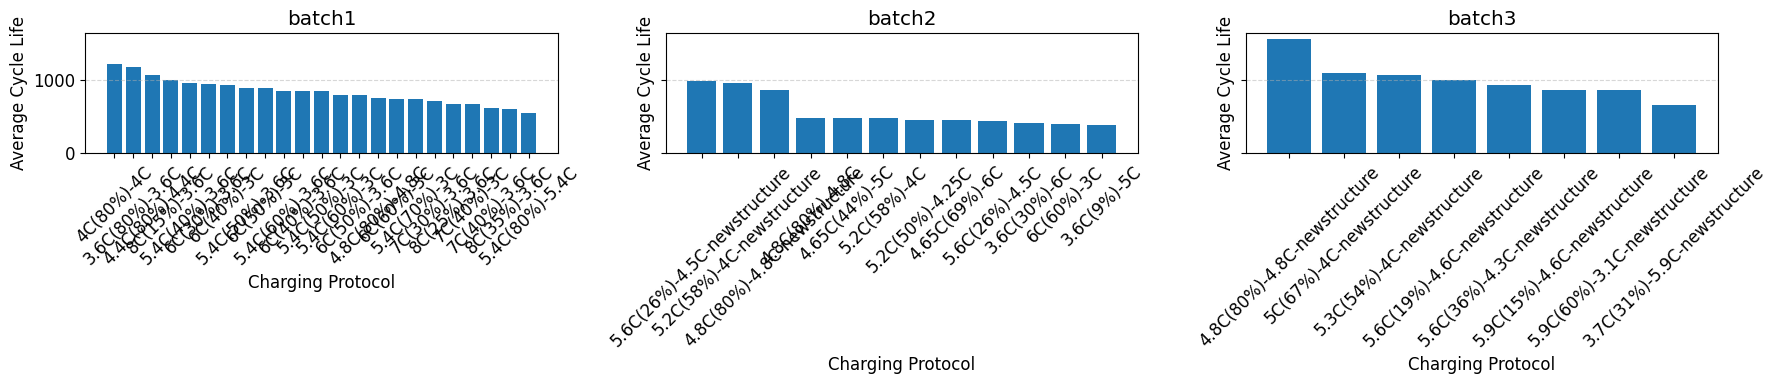

In [56]:
# -----------------------------
# 1) 충전 프로토콜별 평균 수명
# -----------------------------
policy_summary = (
    df.groupby(["batch_label", "policy_readable"])["cycle_life"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values(["batch_label", "mean"], ascending=[True, False])
)

display(policy_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = policy_summary[policy_summary["batch_label"] == b].sort_values("mean", ascending=False)
    ax.bar(sub["policy_readable"], sub["mean"])
    ax.set_title(b)
    ax.set_xlabel("Charging Protocol")
    ax.set_ylabel("Average Cycle Life")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


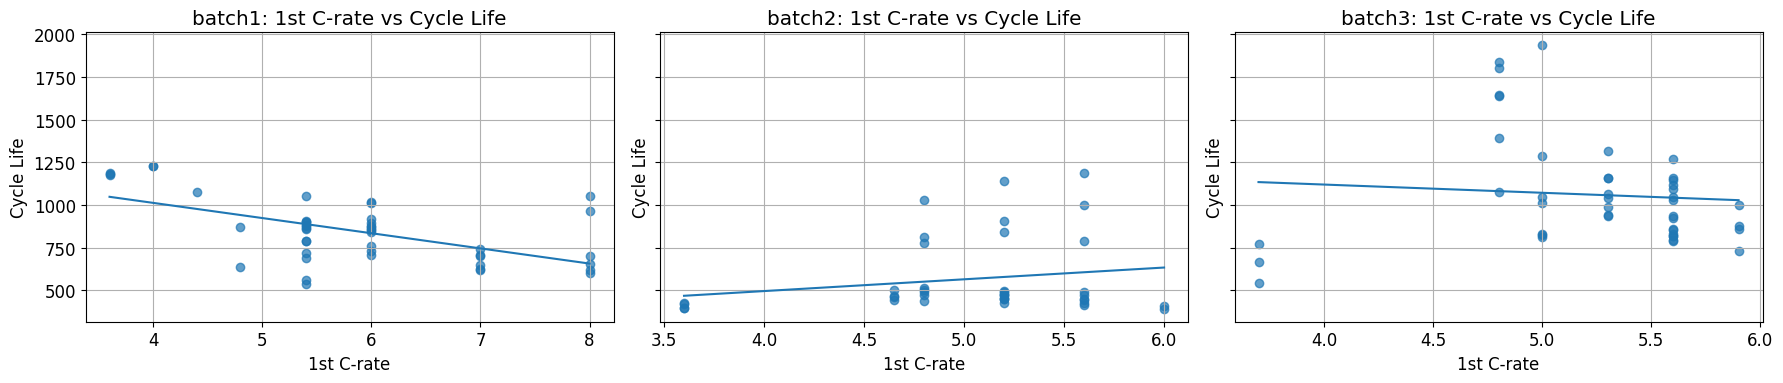

,batch_label,first_c_rate,count,mean,median
0,batch1,3.60,3,1182.000000,1179.0
1,batch1,4.00,2,1226.500000,1226.5
2,batch1,4.40,1,1074.000000,1074.0
3,batch1,4.80,2,753.000000,753.0
4,batch1,5.40,14,808.285714,859.5
5,batch1,6.00,12,861.500000,865.0
6,batch1,7.00,6,673.166667,675.5
7,batch1,8.00,6,764.166667,676.5
8,batch2,3.60,4,407.750000,406.0
9,batch2,4.65,4,467.250000,463.0


In [57]:
# -----------------------------
# 2) 고속 충전이 정말 수명이 짧은가?
# -----------------------------
# first_c_rate 기준으로 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = df[df["batch_label"] == b].dropna(subset=["first_c_rate", "cycle_life"])
    ax.scatter(sub["first_c_rate"], sub["cycle_life"], alpha=0.7)
    if len(sub) >= 2:
        z = np.polyfit(sub["first_c_rate"], sub["cycle_life"], 1)
        x = np.linspace(sub["first_c_rate"].min(), sub["first_c_rate"].max(), 100)
        ax.plot(x, z[0] * x + z[1])
    ax.set_title(f"{b}: 1st C-rate vs Cycle Life")
    ax.set_xlabel("1st C-rate")
    ax.set_ylabel("Cycle Life")
    ax.grid()

plt.tight_layout()
plt.show()

highrate_summary = (
    df.groupby(["batch_label", "first_c_rate"])["cycle_life"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values(["batch_label", "first_c_rate"])
)

display(highrate_summary)

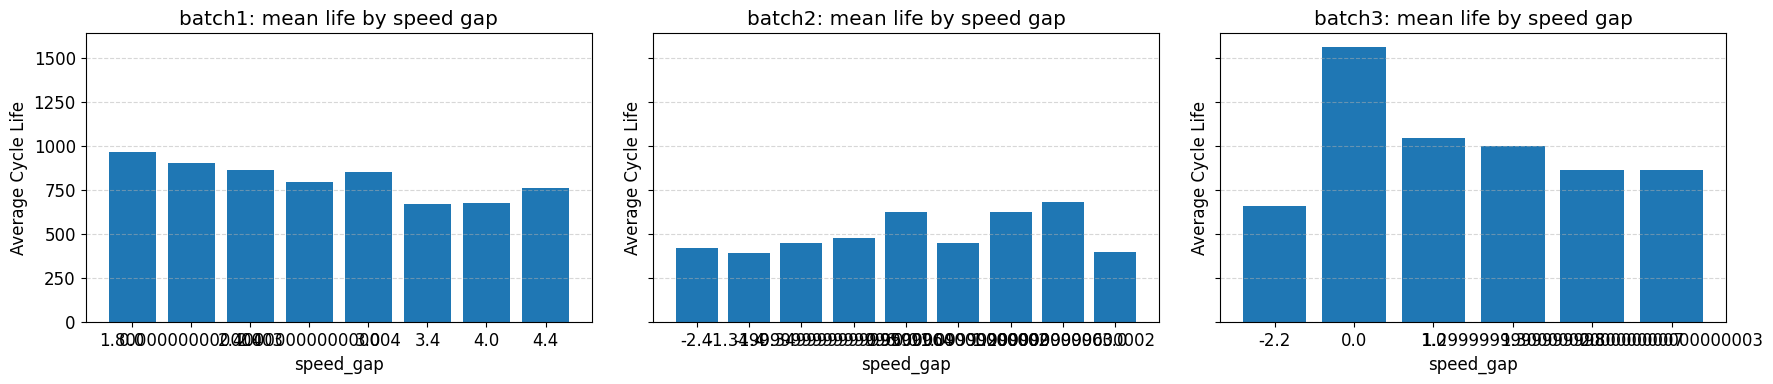

In [58]:
# -----------------------------
# 3) 속도 차이(speed_gap)와 수명
# -----------------------------
gap_mean = (
    df.dropna(subset=["speed_gap", "cycle_life"])
    .groupby(["batch_label", "speed_gap"])["cycle_life"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = gap_mean[gap_mean["batch_label"] == b]
    ax.bar(sub["speed_gap"].astype(str), sub["cycle_life"])
    ax.set_title(f"{b}: mean life by speed gap")
    ax.set_xlabel("speed_gap")
    ax.set_ylabel("Average Cycle Life")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

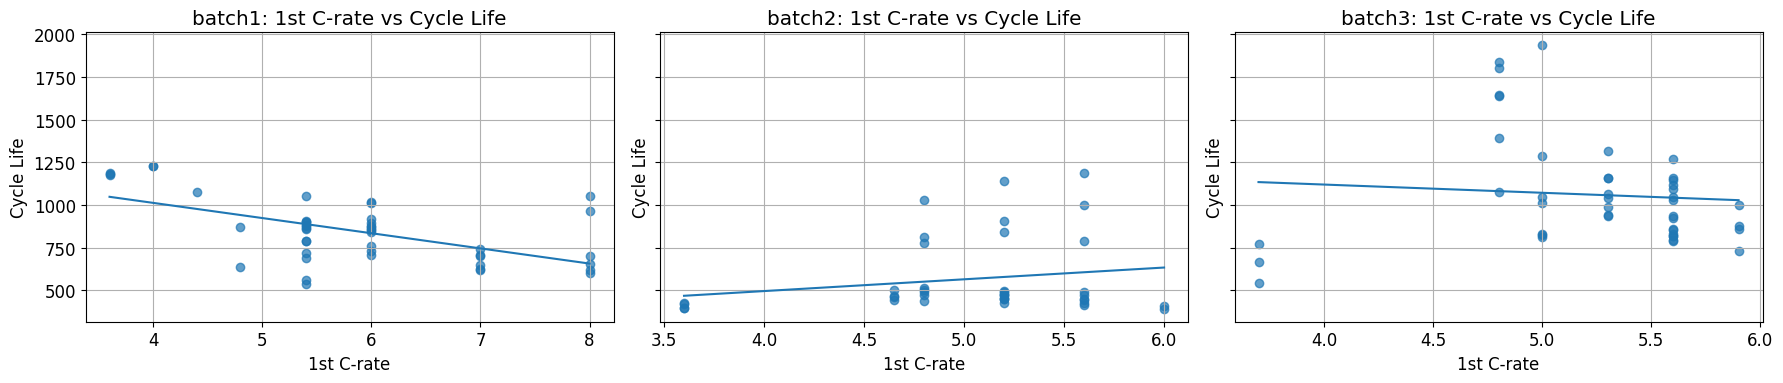

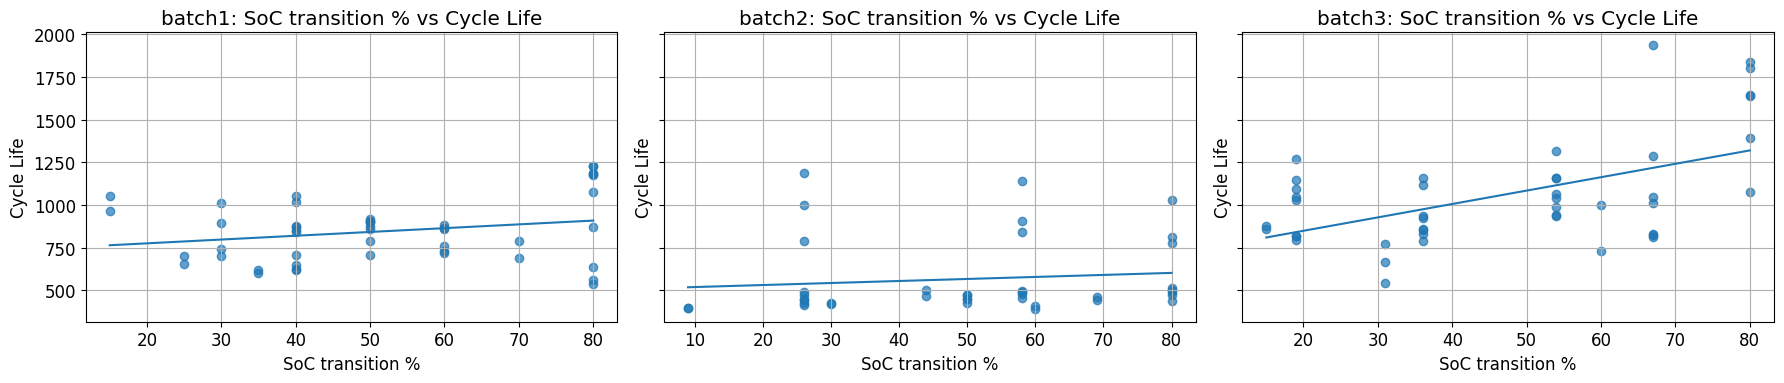

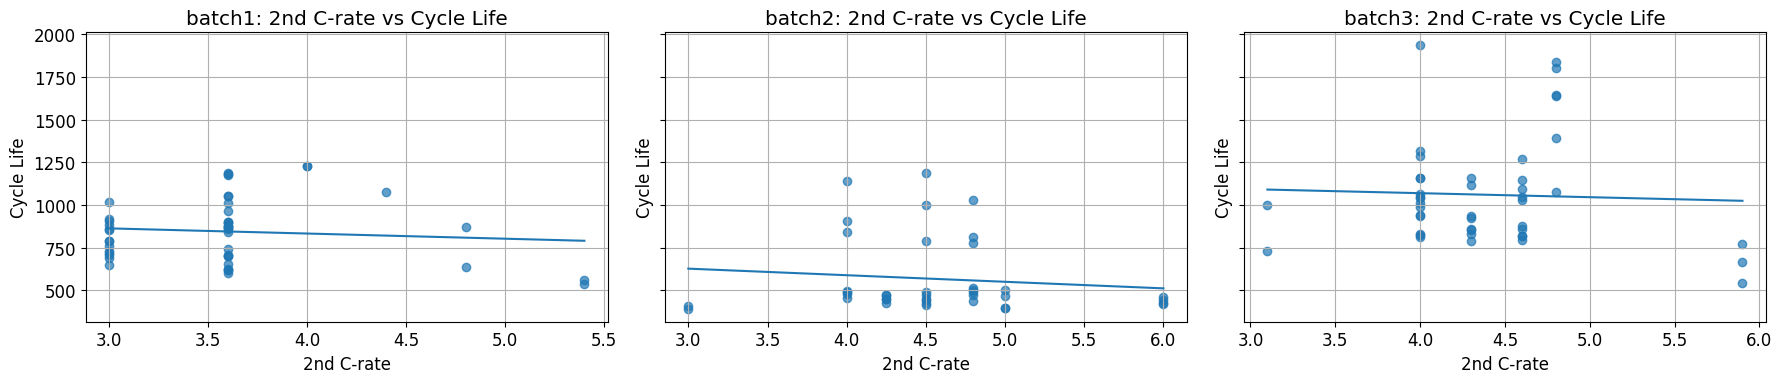

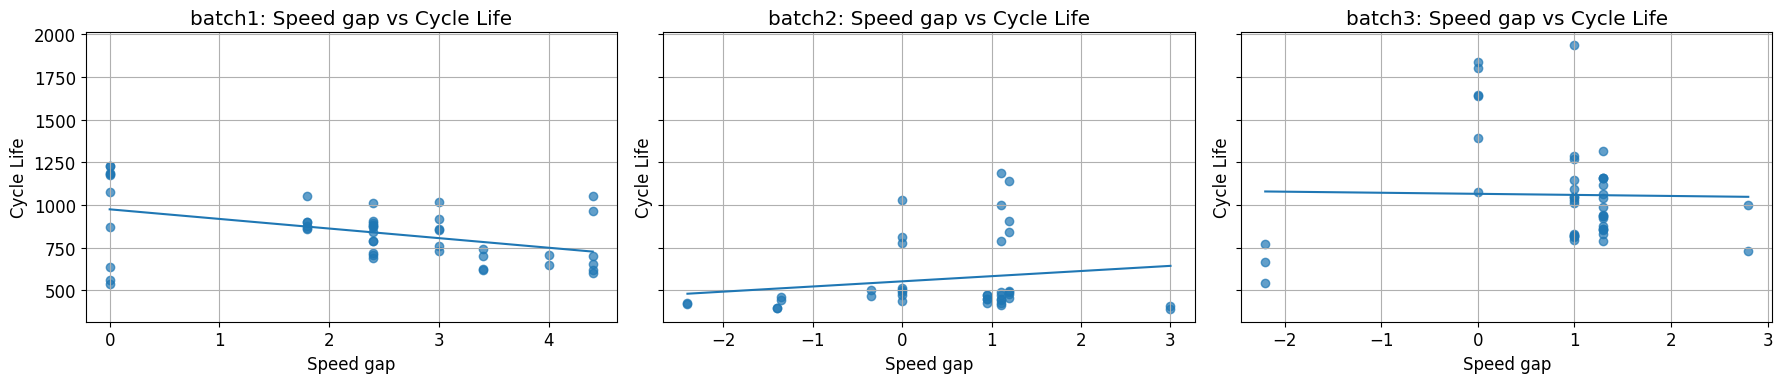

In [59]:
# -----------------------------
# 4) 충전 변수 vs 수명 (batch별)
# -----------------------------
xcols = ["first_c_rate", "soc_percent", "second_c_rate", "speed_gap"]
titles = ["1st C-rate", "SoC transition %", "2nd C-rate", "Speed gap"]

for xcol, title in zip(xcols, titles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
        sub = df[df["batch_label"] == b].dropna(subset=[xcol, "cycle_life"])
        ax.scatter(sub[xcol], sub["cycle_life"], alpha=0.7)
        if len(sub) >= 2:
            z = np.polyfit(sub[xcol], sub["cycle_life"], 1)
            x = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
            ax.plot(x, z[0] * x + z[1])
        ax.set_title(f"{b}: {title} vs Cycle Life")
        ax.set_xlabel(title)
        ax.set_ylabel("Cycle Life")
        ax.grid()
    plt.tight_layout()
    plt.show()

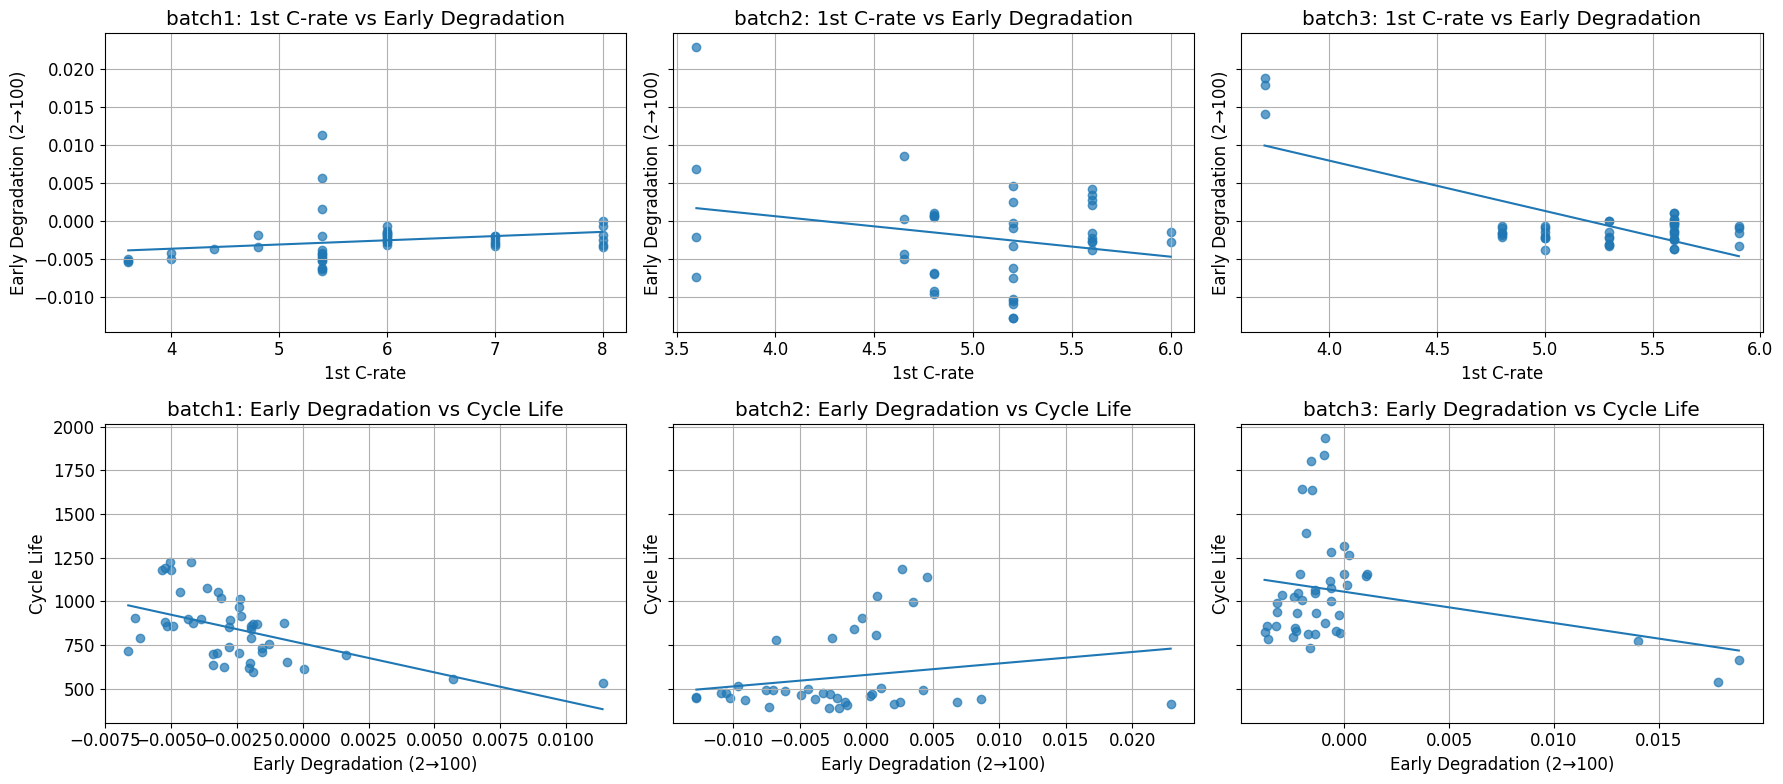

In [60]:
# -----------------------------
# 5) 충전 전류 패턴과 초기 열화 속도
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')

for j, b in enumerate(["batch1", "batch2", "batch3"]):
    sub = df[df["batch_label"] == b].dropna(subset=["first_c_rate", "early_degradation_100"])
    axes[0, j].scatter(sub["first_c_rate"], sub["early_degradation_100"], alpha=0.7)
    if len(sub) >= 2:
        z = np.polyfit(sub["first_c_rate"], sub["early_degradation_100"], 1)
        x = np.linspace(sub["first_c_rate"].min(), sub["first_c_rate"].max(), 100)
        axes[0, j].plot(x, z[0] * x + z[1])
    axes[0, j].set_title(f"{b}: 1st C-rate vs Early Degradation")
    axes[0, j].set_xlabel("1st C-rate")
    axes[0, j].set_ylabel("Early Degradation (2→100)")
    axes[0, j].grid()

    sub2 = df[df["batch_label"] == b].dropna(subset=["early_degradation_100", "cycle_life"])
    axes[1, j].scatter(sub2["early_degradation_100"], sub2["cycle_life"], alpha=0.7)
    if len(sub2) >= 2:
        z = np.polyfit(sub2["early_degradation_100"], sub2["cycle_life"], 1)
        x = np.linspace(sub2["early_degradation_100"].min(), sub2["early_degradation_100"].max(), 100)
        axes[1, j].plot(x, z[0] * x + z[1])
    axes[1, j].set_title(f"{b}: Early Degradation vs Cycle Life")
    axes[1, j].set_xlabel("Early Degradation (2→100)")
    axes[1, j].set_ylabel("Cycle Life")
    axes[1, j].grid()

plt.tight_layout()
plt.show()

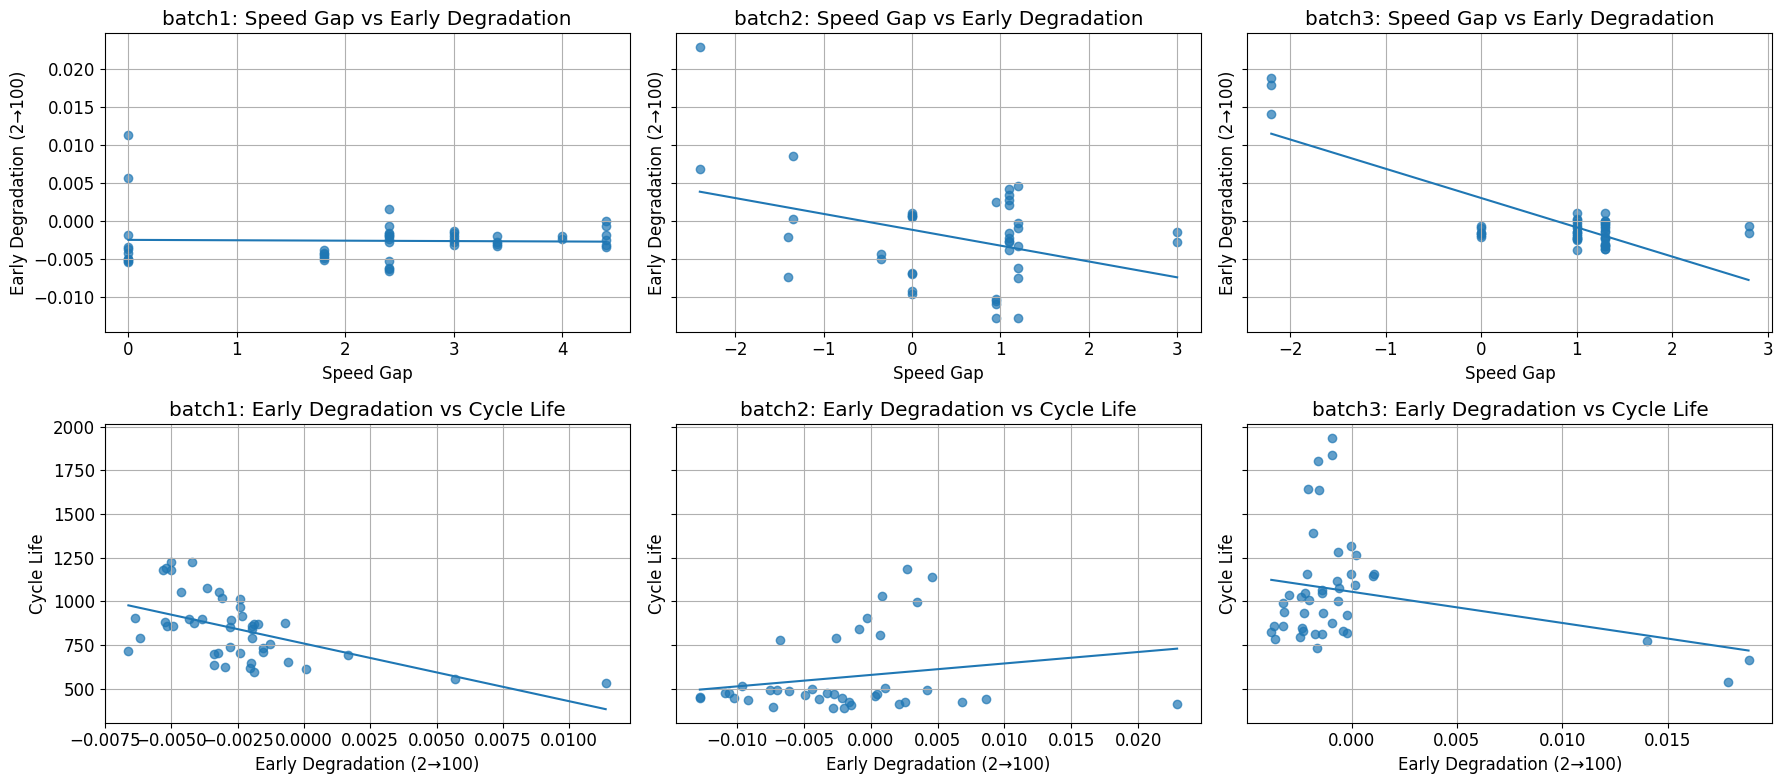

In [61]:
# -----------------------------
# 6) speed_gap vs 초기 열화, 초기 열화 vs 수명
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')

for j, b in enumerate(["batch1", "batch2", "batch3"]):
    sub = df[df["batch_label"] == b].dropna(subset=["speed_gap", "early_degradation_100"])
    axes[0, j].scatter(sub["speed_gap"], sub["early_degradation_100"], alpha=0.7)
    if len(sub) >= 2:
        z = np.polyfit(sub["speed_gap"], sub["early_degradation_100"], 1)
        x = np.linspace(sub["speed_gap"].min(), sub["speed_gap"].max(), 100)
        axes[0, j].plot(x, z[0] * x + z[1])
    axes[0, j].set_title(f"{b}: Speed Gap vs Early Degradation")
    axes[0, j].set_xlabel("Speed Gap")
    axes[0, j].set_ylabel("Early Degradation (2→100)")
    axes[0, j].grid()

    sub2 = df[df["batch_label"] == b].dropna(subset=["early_degradation_100", "cycle_life"])
    axes[1, j].scatter(sub2["early_degradation_100"], sub2["cycle_life"], alpha=0.7)
    if len(sub2) >= 2:
        z = np.polyfit(sub2["early_degradation_100"], sub2["cycle_life"], 1)
        x = np.linspace(sub2["early_degradation_100"].min(), sub2["early_degradation_100"].max(), 100)
        axes[1, j].plot(x, z[0] * x + z[1])
    axes[1, j].set_title(f"{b}: Early Degradation vs Cycle Life")
    axes[1, j].set_xlabel("Early Degradation (2→100)")
    axes[1, j].set_ylabel("Cycle Life")
    axes[1, j].grid()

plt.tight_layout()
plt.show()

In [62]:
# -----------------------------
# 7) batch별 상관 분석
# -----------------------------
corr_features = [
    "first_c_rate", "soc_percent", "second_c_rate",
    "speed_gap", "early_degradation_100", "cycle_life"
]

corr_rows = []
for b, sub in df.groupby("batch_label"):
    corr = sub[corr_features].corr(numeric_only=True)["cycle_life"].drop("cycle_life")
    for feat, val in corr.items():
        corr_rows.append({
            "batch_label": b,
            "feature": feat,
            "corr_with_cycle_life": val
        })

corr_by_batch = pd.DataFrame(corr_rows).sort_values(
    ["batch_label", "corr_with_cycle_life"], ascending=[True, False]
)

display(corr_by_batch)

,batch_label,feature,corr_with_cycle_life
1,batch1,soc_percent,0.234551
2,batch1,second_c_rate,-0.095887
3,batch1,speed_gap,-0.442351
4,batch1,early_degradation_100,-0.539508
0,batch1,first_c_rate,-0.579719
9,batch2,early_degradation_100,0.199276
5,batch2,first_c_rate,0.190747
8,batch2,speed_gap,0.163034
6,batch2,soc_percent,0.116120
7,batch2,second_c_rate,-0.116305


,first_c_rate,soc_percent,second_c_rate,speed_gap,early_degradation_100,cycle_life
first_c_rate,1.000,-0.411,-0.541,0.905,-0.182,-0.078
soc_percent,-0.411,1.000,-0.028,-0.245,-0.159,0.222
second_c_rate,-0.541,-0.028,1.000,-0.848,0.485,-0.125
speed_gap,0.905,-0.245,-0.848,1.000,-0.361,0.014
early_degradation_100,-0.182,-0.159,0.485,-0.361,1.000,-0.011
cycle_life,-0.078,0.222,-0.125,0.014,-0.011,1.000


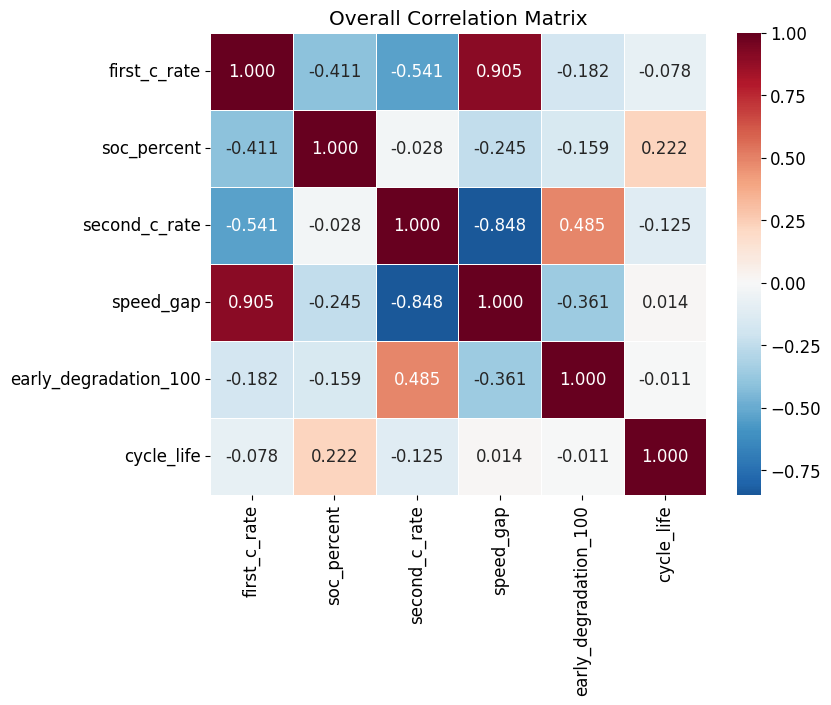

In [65]:
# 전체 상관행렬
overall_corr = df[corr_features].corr(numeric_only=True)
display(overall_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(overall_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Overall Correlation Matrix")
plt.show()

### 5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?
    - 초기 사이클 피켜들과 Cycle Life 상관 계수 확인
    - 가장 강한 관계 식별
    - 멀티클리니어리티 문제 확인

In [ ]:
# -----------------------------
# helper
# -----------------------------
def _to_1d(arr):
    arr = np.asarray(arr, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]

def early_mean(arr, n=100):
    arr = _to_1d(arr)
    if len(arr) < n:
        return np.nan
    return float(np.mean(arr[:n]))

def delta_100(arr):
    arr = _to_1d(arr)
    if len(arr) < 100:
        return np.nan
    return float(arr[99] - arr[0])

def delta_100_10(arr):
    arr = _to_1d(arr)
    if len(arr) < 100:
        return np.nan
    return float(arr[99] - arr[9])

def early_var(arr, n=100):
    arr = _to_1d(arr)
    if len(arr) < n:
        return np.nan
    return float(np.var(arr[:n]))

def build_feature_df(batch, batch_label):
    rows = []
    for cell_id, cell in enumerate(batch):
        summary = cell.get("summary", {})
        cycle_life = _to_scalar(cell.get("cycle_life"))
        if not np.isfinite(cycle_life):
            continue

        row = {
            "batch_label": batch_label,
            "cell_id": cell_id,
            "cycle_life": cycle_life,

            "IR_mean": early_mean(summary.get("IR", [])),
            "QDischarge_mean": early_mean(summary.get("QDischarge", summary.get("Qd", []))),
            "Tmax_mean": early_mean(summary.get("Tmax", [])),
            "Tavg_mean": early_mean(summary.get("Tavg", [])),
            "charge_time_mean": early_mean(summary.get("chargetime", [])),

            "IR_delta": delta_100(summary.get("IR", [])),
            "QDischarge_delta": delta_100(summary.get("QDischarge", summary.get("Qd", []))),
            "IR_delta_100_10": delta_100_10(summary.get("IR", [])),
            "QDischarge_delta_100_10": delta_100_10(summary.get("QDischarge", summary.get("Qd", []))),

            "IR_var": early_var(summary.get("IR", [])),
            "QDischarge_var": early_var(summary.get("QDischarge", summary.get("Qd", []))),
        }
        rows.append(row)

    return pd.DataFrame(rows)

def compute_vif(df_num):
    # 외부 패키지 없이 간단 VIF 계산
    out = []
    X = df_num.dropna().copy()
    if len(X) < 10 or X.shape[1] < 2:
        return pd.DataFrame(columns=["feature", "VIF"])

    for col in X.columns:
        y = X[col].values
        X_others = X.drop(columns=[col]).values

        # 상수항 추가
        X_design = np.column_stack([np.ones(len(X_others)), X_others])

        try:
            beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
            y_pred = X_design @ beta
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)

            if ss_tot == 0:
                vif = np.nan
            else:
                r2 = 1 - ss_res / ss_tot
                vif = np.inf if r2 >= 0.9999 else 1 / (1 - r2)

        except Exception:
            vif = np.nan

        out.append({"feature": col, "VIF": vif})

    return pd.DataFrame(out).sort_values("VIF", ascending=False)

In [67]:
# -----------------------------
# build all-batch feature df
# -----------------------------
feature_df = pd.concat(
    [build_feature_df(batch, batch_label) for batch_label, batch in BATCHES.items()],
    ignore_index=True
)

feature_df = feature_df.dropna().reset_index(drop=True)

print("전체 유효 샘플 수:", len(feature_df))
display(feature_df.head())

feature_cols = [
    "IR_mean", "QDischarge_mean", "Tmax_mean", "Tavg_mean", "charge_time_mean",
    "IR_delta", "QDischarge_delta", "IR_delta_100_10", "QDischarge_delta_100_10",
    "IR_var", "QDischarge_var"
]

전체 유효 샘플 수: 129


,batch_label,cell_id,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var
0,batch1,0,1190.0,0.016477,1.069791,35.022981,31.287710,13.250388,0.016667,1.075913,0.000095,0.001375,0.000003,0.013685
1,batch1,1,1179.0,0.016583,1.070434,33.819048,31.017011,13.240949,0.016997,1.080630,0.000129,0.000853,0.000006,0.011575
2,batch1,2,1177.0,0.016434,1.074517,34.199197,31.164788,13.245097,0.016854,1.084940,0.000167,0.001159,0.000006,0.011664
3,batch1,3,1226.0,0.015985,1.074099,30.355641,29.642777,11.932744,0.016408,1.084750,0.000201,0.000442,0.000005,0.011655
4,batch1,4,1227.0,0.016336,1.072015,34.038691,31.134395,11.932781,0.016734,1.082646,0.000118,0.000692,0.000005,0.011609


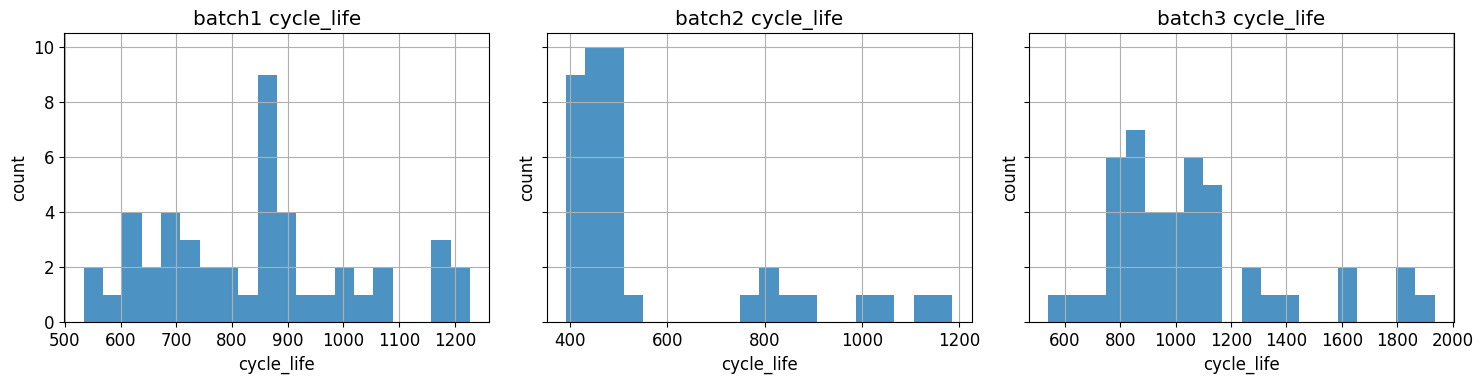

In [68]:
# -----------------------------
# 1) cycle life 분포
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = feature_df[feature_df["batch_label"] == b]
    ax.hist(sub["cycle_life"], bins=20, alpha=0.8)
    ax.set_title(f"{b} cycle_life")
    ax.set_xlabel("cycle_life")
    ax.set_ylabel("count")
    ax.grid()
plt.tight_layout()
plt.show()

In [69]:
# -----------------------------
# 2) batch별 feature vs cycle_life 상관계수
# -----------------------------
corr_rows = []
for b, sub in feature_df.groupby("batch_label"):
    for col in feature_cols:
        tmp = sub[[col, "cycle_life"]].dropna()
        pearson = tmp[col].corr(tmp["cycle_life"], method="pearson") if len(tmp) >= 5 else np.nan
        spearman = tmp[col].corr(tmp["cycle_life"], method="spearman") if len(tmp) >= 5 else np.nan
        corr_rows.append({
            "batch_label": b,
            "feature": col,
            "pearson": pearson,
            "spearman": spearman,
            "abs_spearman": abs(spearman) if pd.notna(spearman) else np.nan,
            "n": len(tmp)
        })

corr_by_batch = pd.DataFrame(corr_rows).sort_values(
    ["batch_label", "abs_spearman"], ascending=[True, False]
)

display(corr_by_batch)

# 가장 강한 관계
strongest_signal = (
    corr_by_batch.groupby("batch_label")
    .head(1)
    .reset_index(drop=True)
)
display(strongest_signal)

,batch_label,feature,pearson,spearman,abs_spearman,n
4,batch1,charge_time_mean,0.577037,0.613050,0.613050,46
8,batch1,QDischarge_delta_100_10,0.549991,0.612619,0.612619,46
3,batch1,Tavg_mean,-0.481775,-0.371469,0.371469,46
6,batch1,QDischarge_delta,0.295098,0.324288,0.324288,46
2,batch1,Tmax_mean,-0.403596,-0.322992,0.322992,46
5,batch1,IR_delta,0.307470,0.245159,0.245159,46
7,batch1,IR_delta_100_10,0.118457,-0.240286,0.240286,46
10,batch1,QDischarge_var,-0.100834,0.236709,0.236709,46
1,batch1,QDischarge_mean,0.193393,0.185025,0.185025,46
9,batch1,IR_var,0.173550,0.150672,0.150672,46


,batch_label,feature,pearson,spearman,abs_spearman,n
0,batch1,charge_time_mean,0.577037,0.613050,0.613050,46
1,batch2,IR_var,-0.468169,-0.522994,0.522994,39
2,batch3,QDischarge_var,-0.349841,-0.354782,0.354782,44


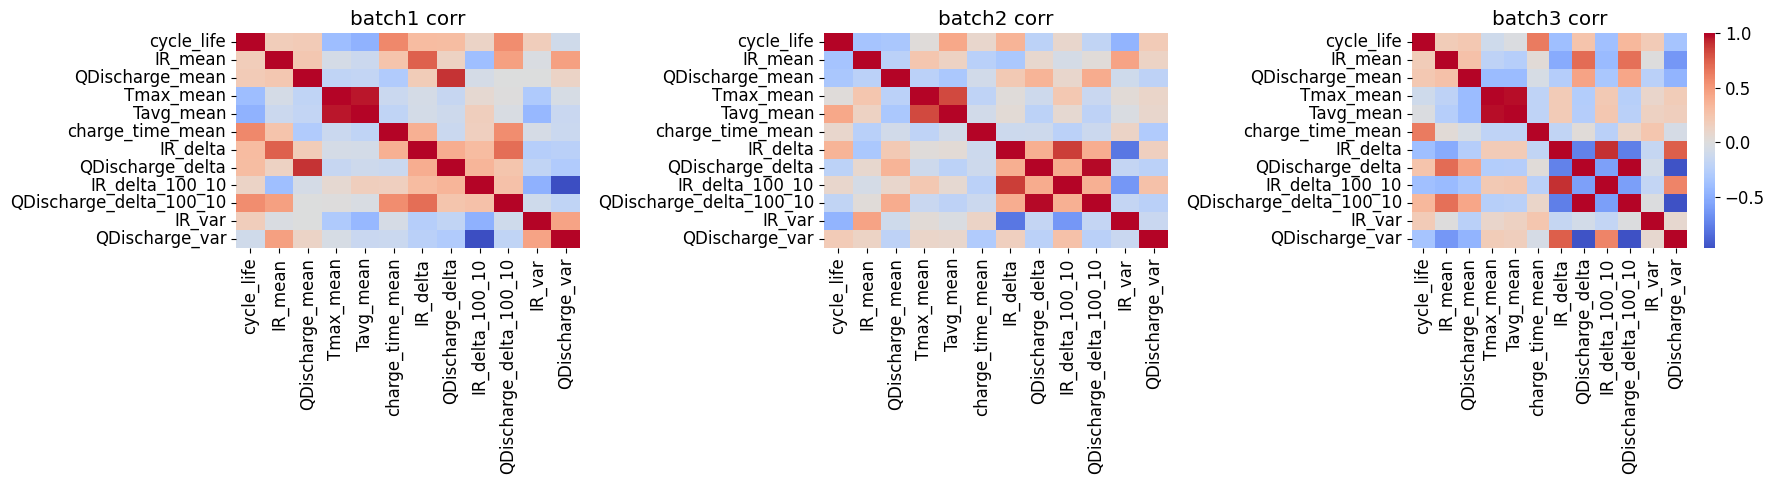

In [70]:
# -----------------------------
# 3) batch별 correlation heatmap
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    sub = feature_df[feature_df["batch_label"] == b][["cycle_life"] + feature_cols]
    corr = sub.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar=(b == "batch3"))
    ax.set_title(f"{b} corr")
plt.tight_layout()
plt.show()

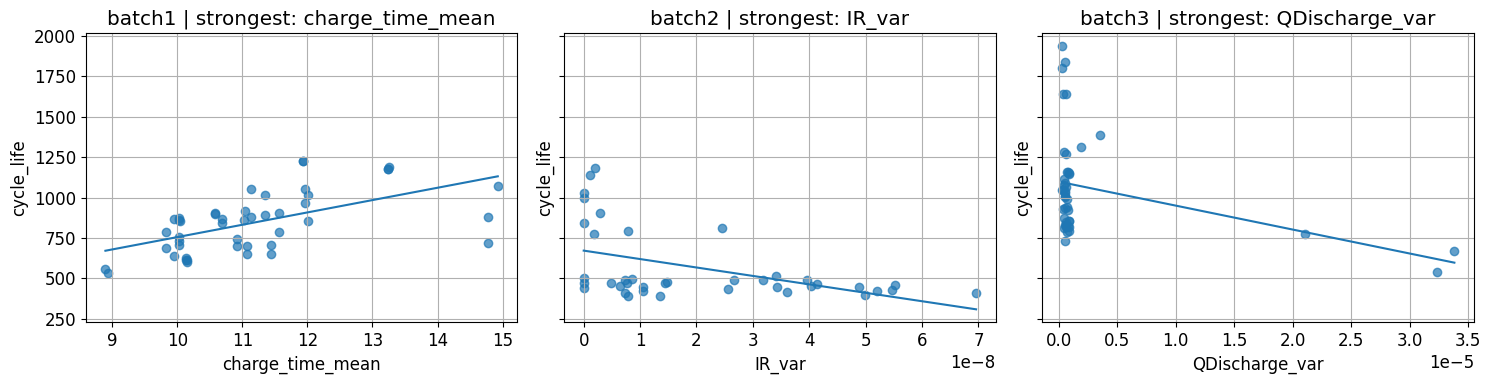

In [71]:
# -----------------------------
# 4) strongest feature scatter
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, b in zip(axes, ["batch1", "batch2", "batch3"]):
    best_feat = strongest_signal.loc[strongest_signal["batch_label"] == b, "feature"].iloc[0]
    sub = feature_df[feature_df["batch_label"] == b][[best_feat, "cycle_life"]].dropna()

    ax.scatter(sub[best_feat], sub["cycle_life"], alpha=0.7)
    if len(sub) >= 2:
        z = np.polyfit(sub[best_feat], sub["cycle_life"], 1)
        x = np.linspace(sub[best_feat].min(), sub[best_feat].max(), 100)
        ax.plot(x, z[0] * x + z[1])

    ax.set_title(f"{b} | strongest: {best_feat}")
    ax.set_xlabel(best_feat)
    ax.set_ylabel("cycle_life")
    ax.grid()

plt.tight_layout()
plt.show()

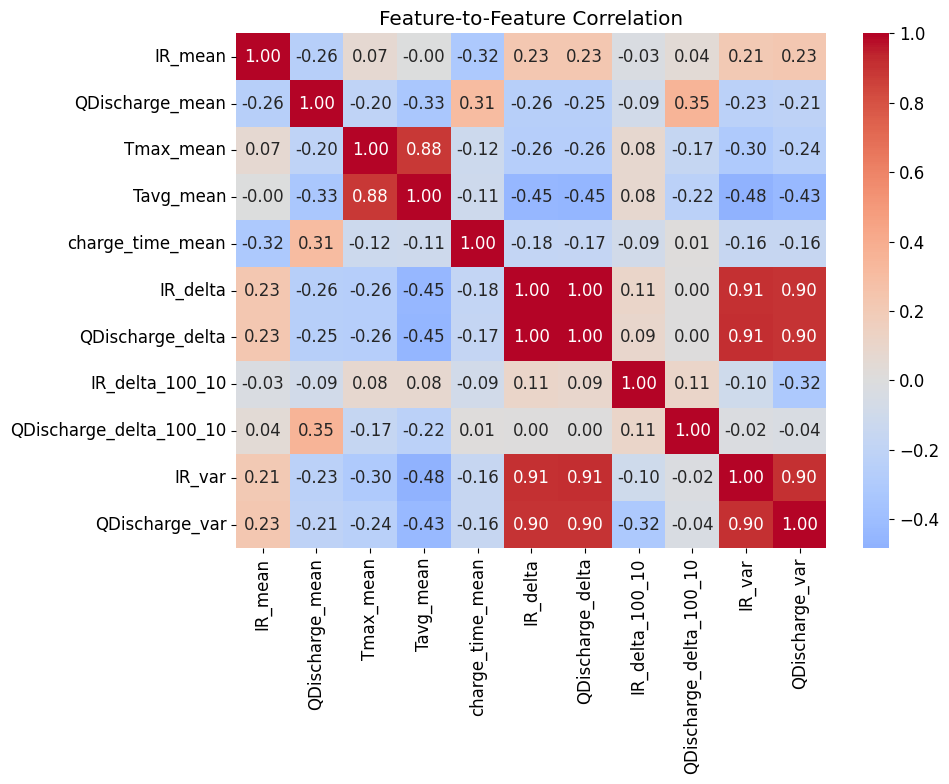

,feature,VIF,batch_label
0,IR_mean,2108.565677,batch1
1,IR_delta,1757.371302,batch1
2,IR_delta_100_10,676.091012,batch1
3,QDischarge_delta,326.908821,batch1
4,QDischarge_var,307.002861,batch1
5,QDischarge_mean,295.164393,batch1
6,IR_var,45.213850,batch1
7,Tavg_mean,30.814439,batch1
8,Tmax_mean,24.833237,batch1
9,QDischarge_delta_100_10,13.816065,batch1


In [72]:
# -----------------------------
# 5) 멀티클리니어리티 확인
# -----------------------------
# 5-1. 전체 feature 간 상관
plt.figure(figsize=(10, 8))
sns.heatmap(feature_df[feature_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature-to-Feature Correlation")
plt.tight_layout()
plt.show()

# 5-2. batch별 VIF
vif_all = []
for b, sub in feature_df.groupby("batch_label"):
    vif_df = compute_vif(sub[feature_cols])
    vif_df["batch_label"] = b
    vif_all.append(vif_df)

vif_by_batch = pd.concat(vif_all, ignore_index=True)
display(vif_by_batch.sort_values(["batch_label", "VIF"], ascending=[True, False]))

In [74]:
# =========================================================
# Feature stability across batches (기존 코드 대체)
# =========================================================

# batch별 corr 계산
corr_dict = {}
for b, sub in feature_df.groupby("batch_label"):
    corr = sub.select_dtypes(include=np.number).corr()["cycle_life"]
    corr_dict[b] = corr

# 하나의 테이블로 결합
corr_table = pd.concat(corr_dict, axis=1)

# 컬럼 이름 정리
corr_table.columns = ["Batch1", "Batch2", "Batch3"]

display(corr_table)

,Batch1,Batch2,Batch3
cell_id,-0.601802,0.370594,0.161507
cycle_life,1.000000,1.000000,1.000000
IR_mean,0.176631,-0.352537,0.190233
QDischarge_mean,0.193393,-0.332111,0.217499
Tmax_mean,-0.403596,0.018960,-0.106455
Tavg_mean,-0.481775,0.424616,-0.021817
charge_time_mean,0.577037,0.087033,0.637495
IR_delta,0.307470,0.354646,-0.389579
QDischarge_delta,0.295098,-0.216027,0.252774
IR_delta_100_10,0.118457,0.093367,-0.381459


In [75]:
# -----------------------------
# 안정적인 feature (batch 공통)
# -----------------------------
corr_table["mean_corr"] = abs(corr_table).mean(axis=1)

stable = corr_table[corr_table["mean_corr"] > 0.2]

print("📌 안정적인 feature (mean |corr| > 0.2)")
display(stable.sort_values("mean_corr", ascending=False))

📌 안정적인 feature (mean |corr| > 0.2)


,Batch1,Batch2,Batch3,mean_corr
cycle_life,1.000000,1.000000,1.000000,1.000000
charge_time_mean,0.577037,0.087033,0.637495,0.433855
cell_id,-0.601802,0.370594,0.161507,0.377967
QDischarge_delta_100_10,0.549991,-0.187254,0.329881,0.355709
IR_delta,0.307470,0.354646,-0.389579,0.350565
Tavg_mean,-0.481775,0.424616,-0.021817,0.309403
IR_var,0.173550,-0.468169,0.196196,0.279305
QDischarge_delta,0.295098,-0.216027,0.252774,0.254633
QDischarge_mean,0.193393,-0.332111,0.217499,0.247668
IR_mean,0.176631,-0.352537,0.190233,0.239800


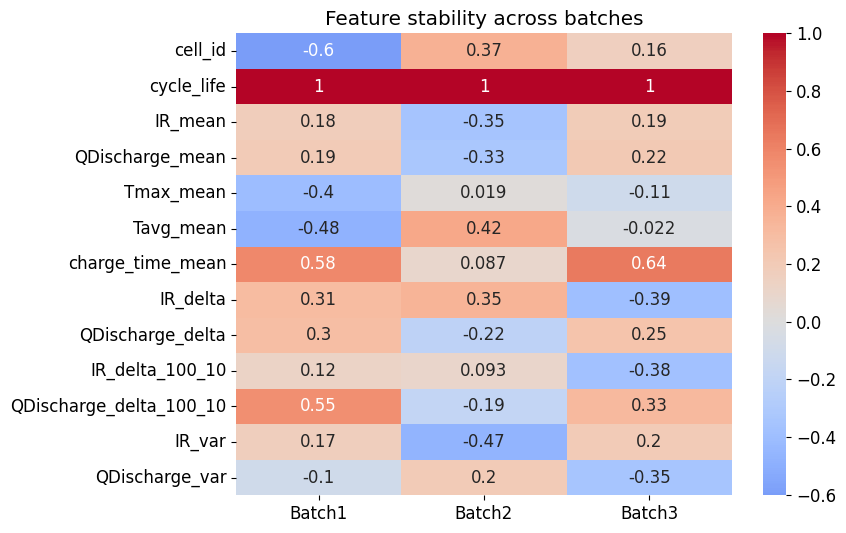

In [76]:
# -----------------------------
# heatmap
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_table.drop(columns=["mean_corr"]), annot=True, cmap="coolwarm", center=0)
plt.title("Feature stability across batches")
plt.show()

In [77]:
# -----------------------------
# 중요도 순 정렬
# -----------------------------
ranked = corr_table.sort_values("mean_corr", ascending=False)

print("📌 Feature importance ranking (mean correlation)")
display(ranked)

📌 Feature importance ranking (mean correlation)


,Batch1,Batch2,Batch3,mean_corr
cycle_life,1.000000,1.000000,1.000000,1.000000
charge_time_mean,0.577037,0.087033,0.637495,0.433855
cell_id,-0.601802,0.370594,0.161507,0.377967
QDischarge_delta_100_10,0.549991,-0.187254,0.329881,0.355709
IR_delta,0.307470,0.354646,-0.389579,0.350565
Tavg_mean,-0.481775,0.424616,-0.021817,0.309403
IR_var,0.173550,-0.468169,0.196196,0.279305
QDischarge_delta,0.295098,-0.216027,0.252774,0.254633
QDischarge_mean,0.193393,-0.332111,0.217499,0.247668
IR_mean,0.176631,-0.352537,0.190233,0.239800
